In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import lazyfca and utils
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA
from utils import estimate_quality

In [2]:
# Load the metric thresholds data
df = pd.read_csv('threshold_results/old_churn_pr_metric_thresholds.csv')
print(f"Loaded {len(df)} rows")
print(f"Metrics: {df['metric_name'].unique()}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Loaded 5625 rows
Metrics: <StringArray>
[        'opposers_covered',                  'support',
               'error_rate',                'precision',
                     'lift',                    'wracc',
 'balanced_precision_proxy',                'youdens_j',
     'matthews_correlation',         'information_gain',
                'gini_gain',           'log_odds_ratio',
              'chi_squared',                   'g_test',
       'interval_tightness',       'description_volume',
         'simplicity_prior',  'query_binary_similarity',
 'query_numeric_similarity',         'query_similarity',
 'query_weighted_precision',     'query_weighted_wracc',
                'stability',               'robustness',
          'delta_stability']
Length: 25, dtype: str

Columns: ['metric_name', 'pos_threshold', 'neg_threshold', 'num_pos_classifiers_passing', 'num_neg_classifiers_passing', 'avg_positive_classifications', 'avg_negative_classifications', 'Accuracy', 'Precision', 'Recall', 'AU

,metric_name,pos_threshold,neg_threshold,num_pos_classifiers_passing,num_neg_classifiers_passing,avg_positive_classifications,avg_negative_classifications,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,opposers_covered,0.0,0.000000,7209,200694,10.473011,285.095170,0.781250,0.657143,0.368984,0.771915,0.472603,69,481,36,118,0.930368,0.803005,0.069632,0.342857
1,opposers_covered,0.0,58.142857,7209,938188,10.473011,1335.333807,0.738636,1.000000,0.016043,0.765316,0.031579,3,517,0,184,1.000000,0.737518,0.000000,0.000000
2,opposers_covered,0.0,116.285714,7209,958186,10.473011,1364.096591,0.737216,1.000000,0.010695,0.765306,0.021164,2,517,0,185,1.000000,0.736467,0.000000,0.000000
3,opposers_covered,0.0,174.428571,7209,963468,10.473011,1371.761364,0.737216,1.000000,0.010695,0.765420,0.021164,2,517,0,185,1.000000,0.736467,0.000000,0.000000
4,opposers_covered,0.0,232.571429,7209,965581,10.473011,1374.818182,0.737216,1.000000,0.010695,0.765414,0.021164,2,517,0,185,1.000000,0.736467,0.000000,0.000000


In [3]:
def plot_both_thresholds_vs_f1(df, metric_name):
    """
    Plot both positive and negative threshold vs max F1-score side by side for a given metric.
    
    Args:
        df: DataFrame with metric threshold results
        metric_name: Name of the metric to plot
    """
    # Filter data for this metric
    metric_df = df[df['metric_name'] == metric_name].copy()
    
    if len(metric_df) == 0:
        print(f"No data found for metric: {metric_name}")
        return
    
    # Create figure with 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    
    # Process both threshold types
    for idx, (threshold_type, ax) in enumerate(zip(['pos', 'neg'], axes)):
        if threshold_type == 'pos':
            threshold_col = 'pos_threshold'
            avg_classifications_col = 'avg_positive_classifications'
            other_avg_classifications_col = 'avg_negative_classifications'
            title_label = 'Positive'
        else:
            threshold_col = 'neg_threshold'
            avg_classifications_col = 'avg_negative_classifications'
            other_avg_classifications_col = 'avg_positive_classifications'
            title_label = 'Negative'
        
        # Group by threshold and get max F1-score
        result_rows = []
        for threshold in metric_df[threshold_col].unique():
            subset = metric_df[metric_df[threshold_col] == threshold]
            max_f1_idx = subset['F1-score'].idxmax()
            max_f1_row = subset.loc[max_f1_idx]
            result_rows.append({
                threshold_col: threshold,
                'F1-score': max_f1_row['F1-score'],
                avg_classifications_col: int(max_f1_row[avg_classifications_col]),
                other_avg_classifications_col: int(max_f1_row[other_avg_classifications_col]),
            })
        
        plot_df = pd.DataFrame(result_rows).sort_values(threshold_col)
        
        thresholds = plot_df[threshold_col].values
        f1_scores = plot_df['F1-score'].values
        main_avg_classifications = plot_df[avg_classifications_col].values
        other_avg_classifications = plot_df[other_avg_classifications_col].values
        
        # Plot on the subplot
        ax.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=6, color='blue')
        
        # Add annotations for each point
        for i, (x, y) in enumerate(zip(thresholds, f1_scores)):
            # Main avg classifications (green) above the point
            ax.annotate(f'{main_avg_classifications[i]}', 
                        xy=(x, y), 
                        xytext=(0, 12),
                        textcoords='offset points',
                        ha='center',
                        fontsize=9,
                        color='green',
                        weight='bold')
            
            # Other avg classifications (red) below the point
            ax.annotate(f'{other_avg_classifications[i]}', 
                        xy=(x, y), 
                        xytext=(0, -18),
                        textcoords='offset points',
                        ha='center',
                        fontsize=9,
                        color='red',
                        weight='bold')
        
        ax.set_xlabel(f'{title_label} Threshold', fontsize=12)
        ax.set_ylabel('Max F1 Score', fontsize=12)
        ax.set_title(f'{title_label} Threshold Analysis\n(Green = Avg {title_label} Class., Red = Avg {"Negative" if threshold_type == "pos" else "Positive"} Class.)', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Show best threshold info
        best_idx = np.argmax(f1_scores)
        print(f"\n{title_label} Threshold Analysis:")
        print(f"  Best threshold: {thresholds[best_idx]:.6f}")
        print(f"  Max F1 score: {f1_scores[best_idx]:.6f}")
        print(f"  Avg {title_label.lower()} classifications: {main_avg_classifications[best_idx]}")
        print(f"  Avg {'negative' if threshold_type == 'pos' else 'positive'} classifications: {other_avg_classifications[best_idx]}")
    
    fig.suptitle(f'Threshold Analysis for {metric_name}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

In [4]:
# Get unique metrics in the dataset
metrics = df['metric_name'].unique()
print(f"Available metrics ({len(metrics)}):")
for i, metric in enumerate(metrics, 1):
    print(f"  {i}. {metric}")

Available metrics (25):
  1. opposers_covered
  2. support
  3. error_rate
  4. precision
  5. lift
  6. wracc
  7. balanced_precision_proxy
  8. youdens_j
  9. matthews_correlation
  10. information_gain
  11. gini_gain
  12. log_odds_ratio
  13. chi_squared
  14. g_test
  15. interval_tightness
  16. description_volume
  17. simplicity_prior
  18. query_binary_similarity
  19. query_numeric_similarity
  20. query_similarity
  21. query_weighted_precision
  22. query_weighted_wracc
  23. stability
  24. robustness
  25. delta_stability



Metric: opposers_covered

Positive Threshold Analysis:
  Best threshold: 565.285714
  Max F1 score: 0.632258
  Avg positive classifications: 825
  Avg negative classifications: 1335

Negative Threshold Analysis:
  Best threshold: 58.142857
  Max F1 score: 0.632258
  Avg negative classifications: 1335
  Avg positive classifications: 825


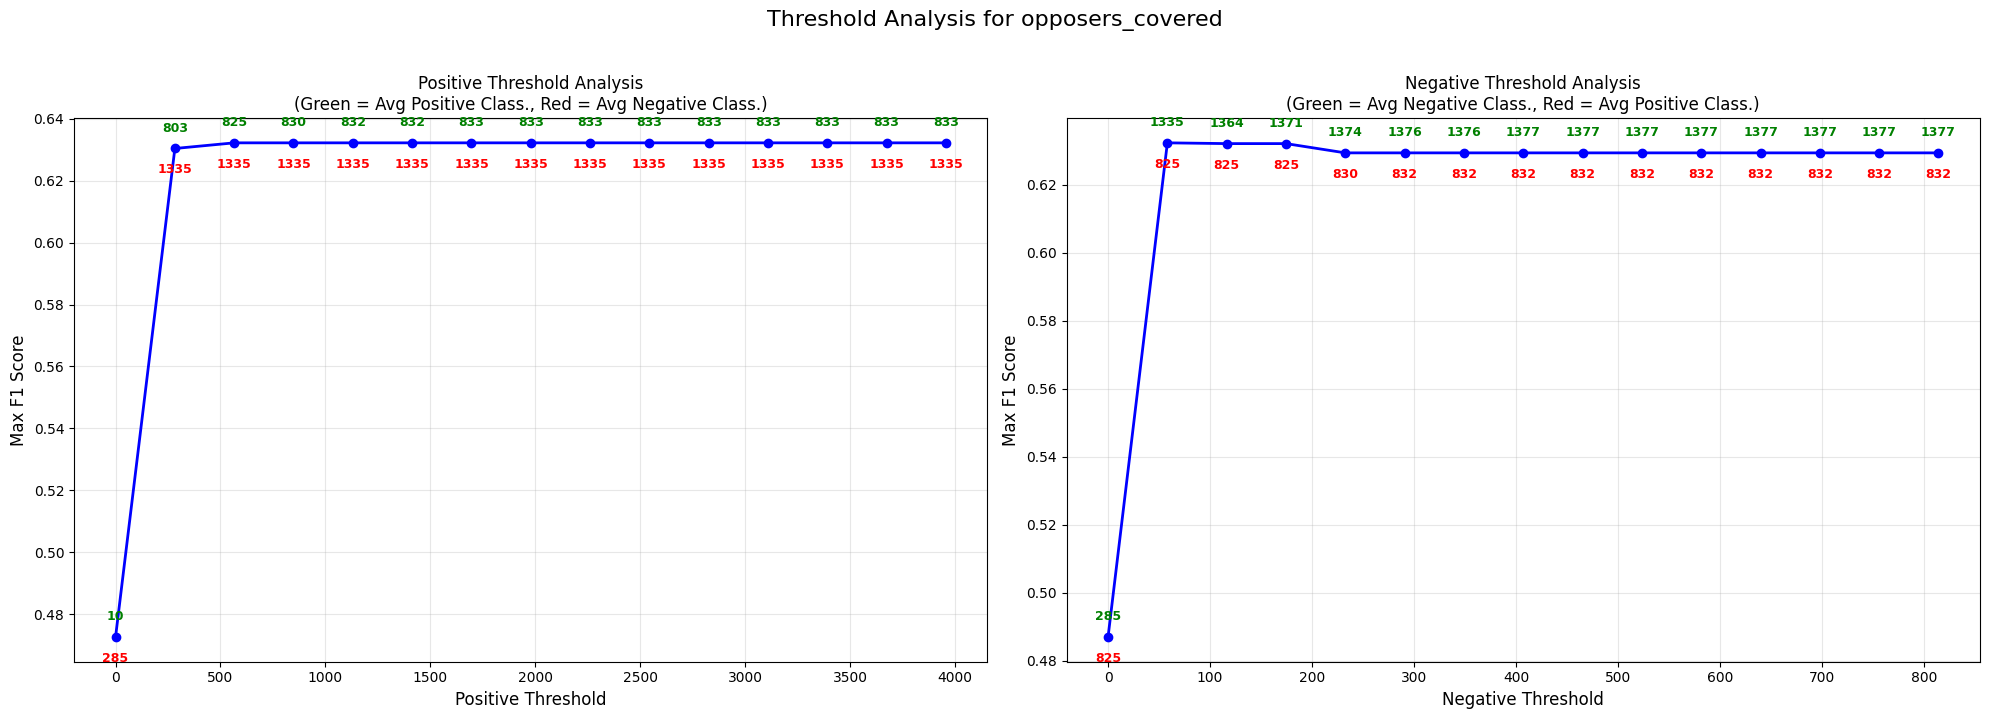


Metric: support

Positive Threshold Analysis:
  Best threshold: 0.002973
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.002152
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


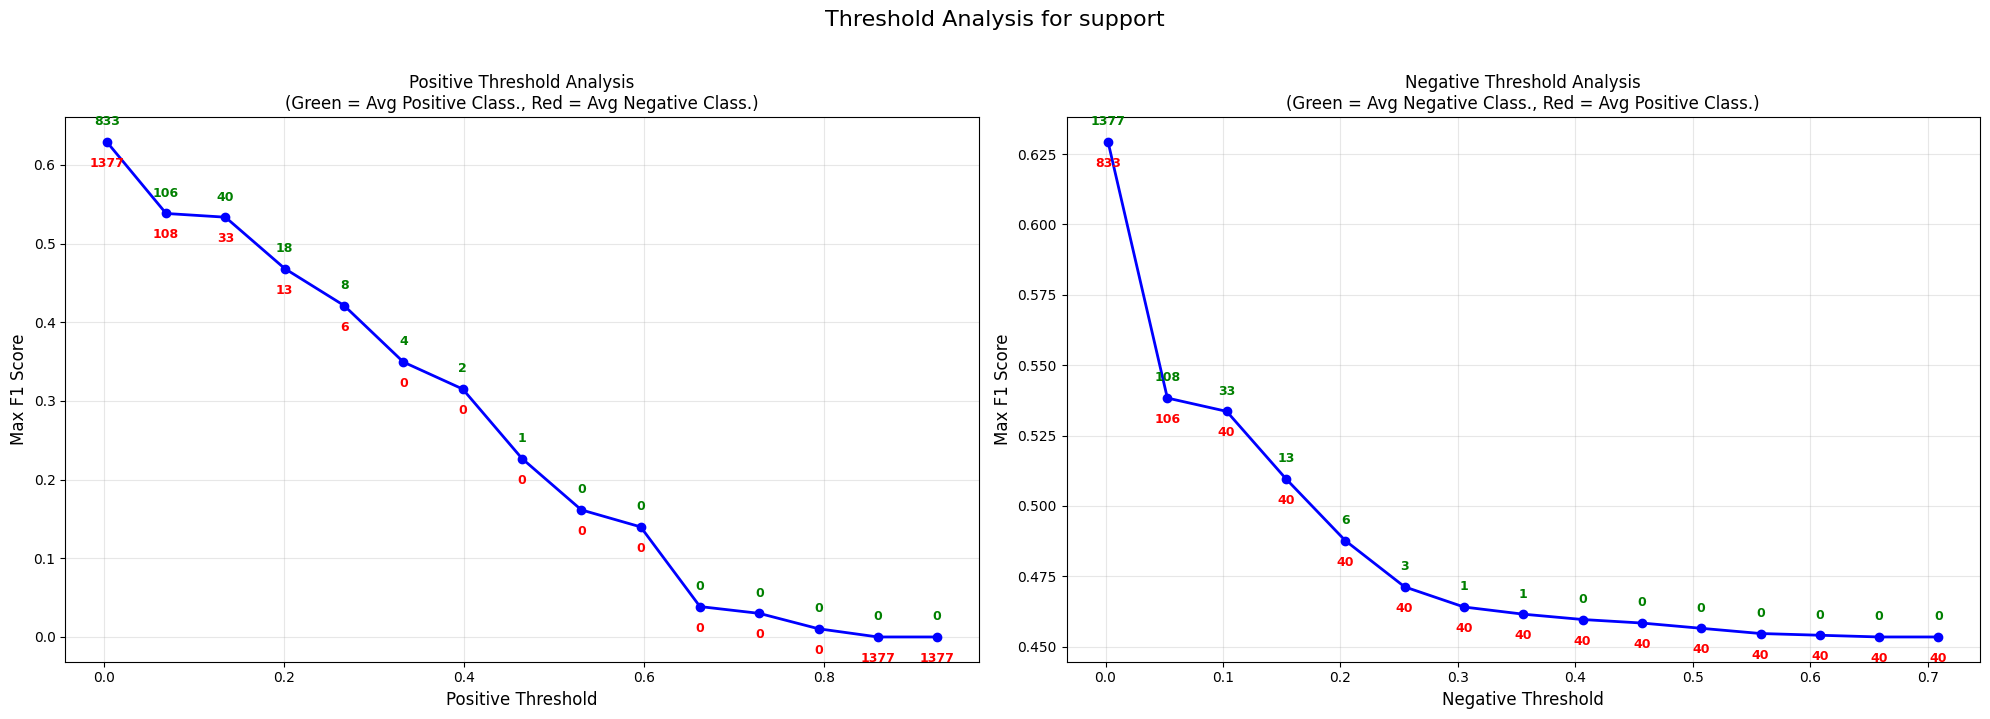


Metric: error_rate

Positive Threshold Analysis:
  Best threshold: 0.121671
  Max F1 score: 0.632258
  Avg positive classifications: 825
  Avg negative classifications: 1335

Negative Threshold Analysis:
  Best threshold: 0.034568
  Max F1 score: 0.632258
  Avg negative classifications: 1335
  Avg positive classifications: 825


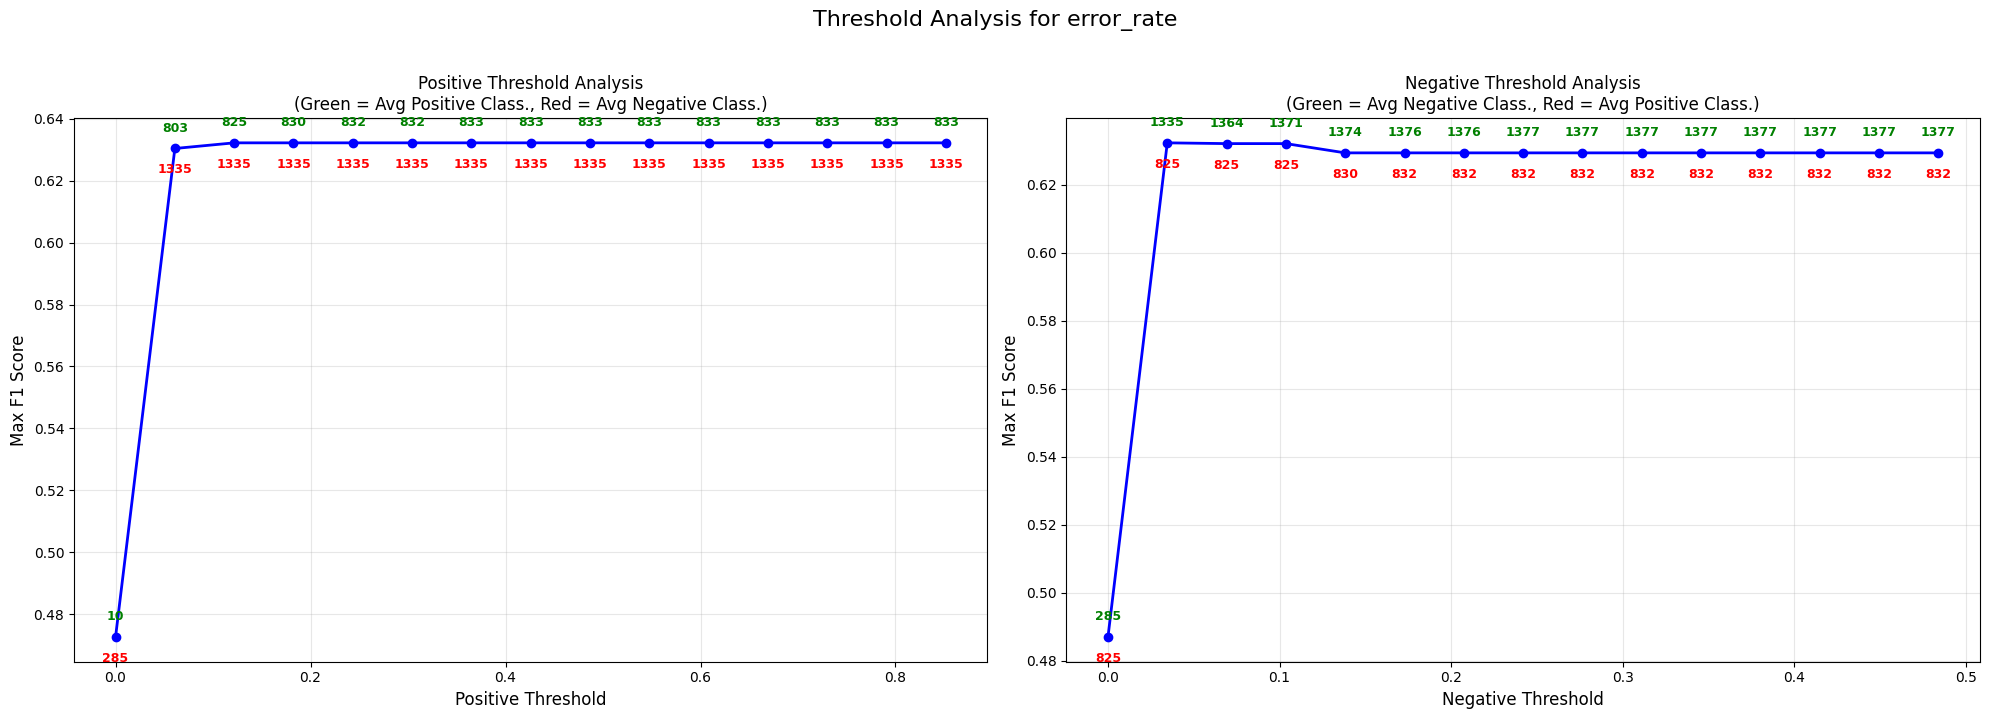


Metric: precision

Positive Threshold Analysis:
  Best threshold: 0.264706
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.800000
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


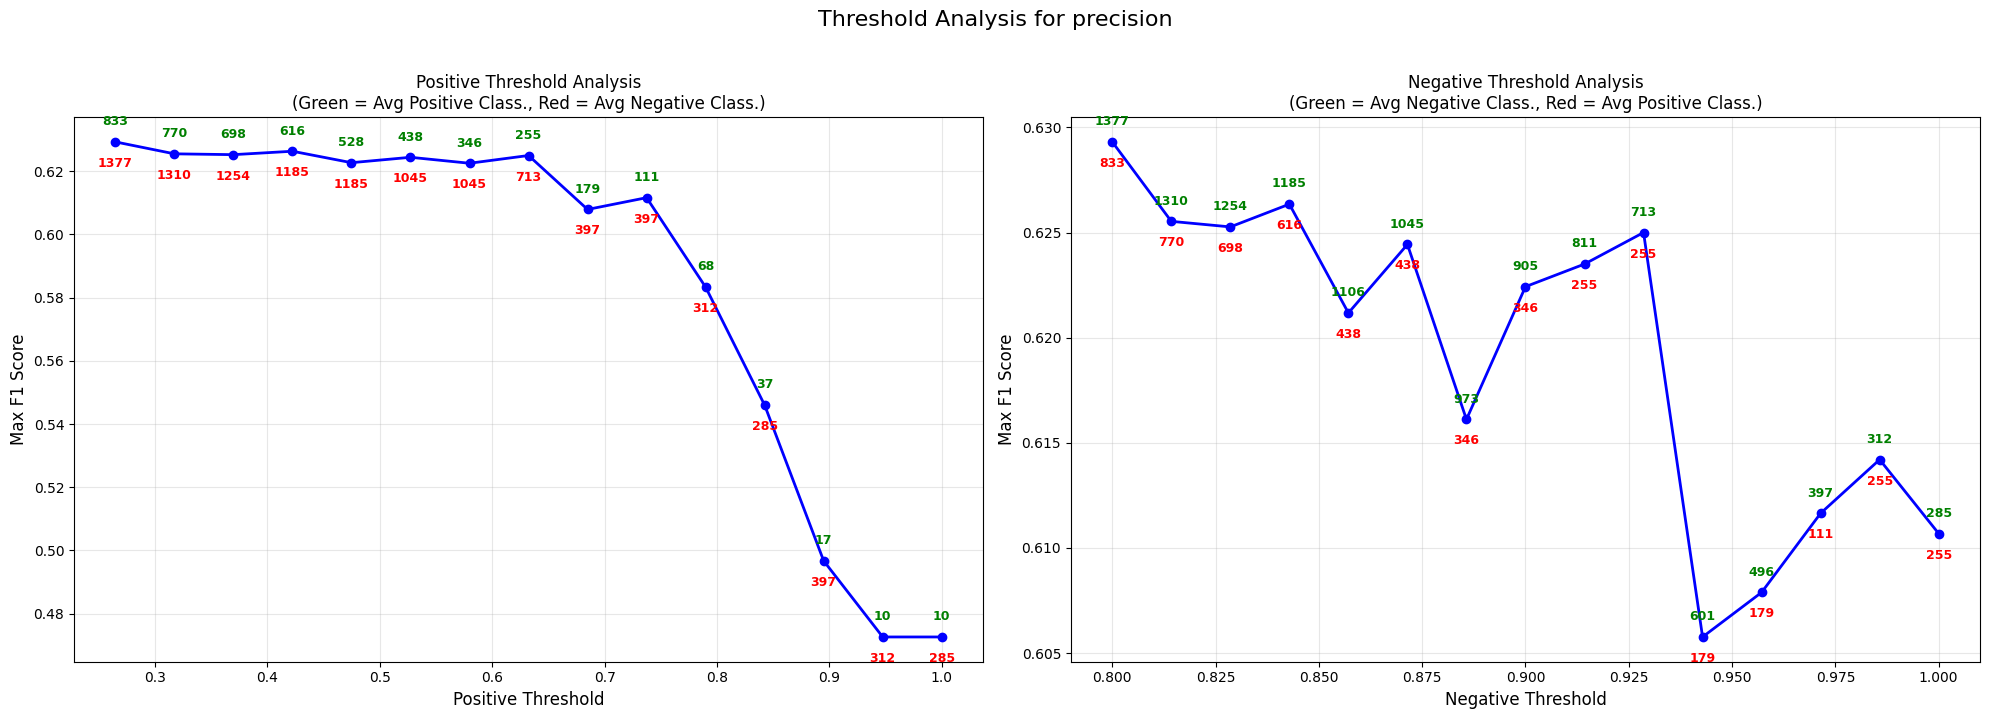


Metric: lift

Positive Threshold Analysis:
  Best threshold: 0.995873
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 1.089625
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


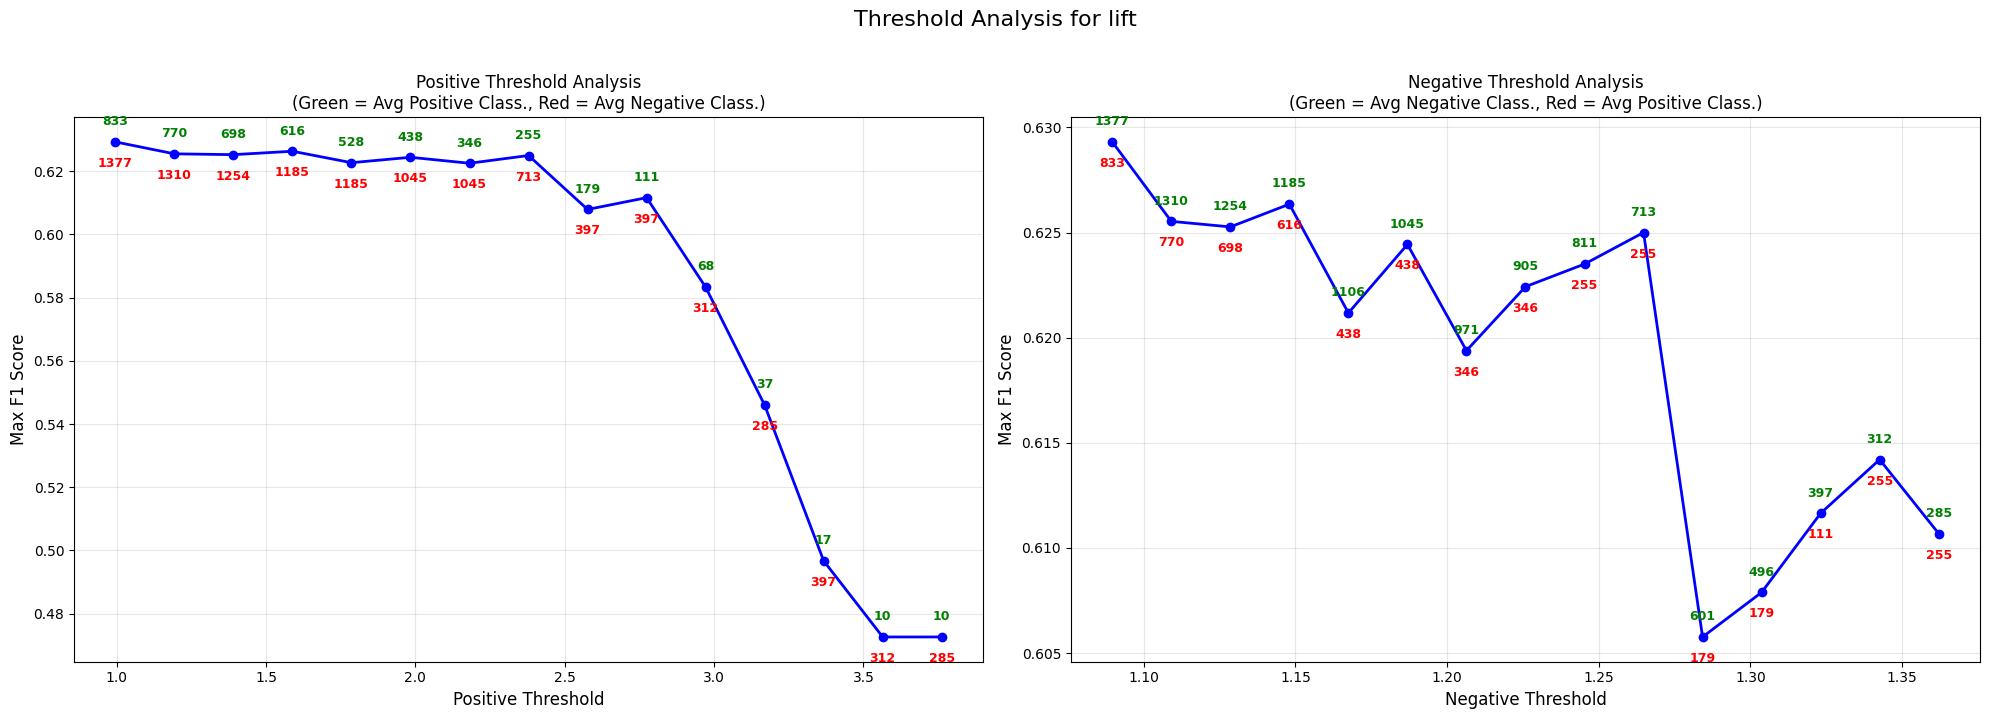


Metric: wracc

Positive Threshold Analysis:
  Best threshold: -0.000338
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000156
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


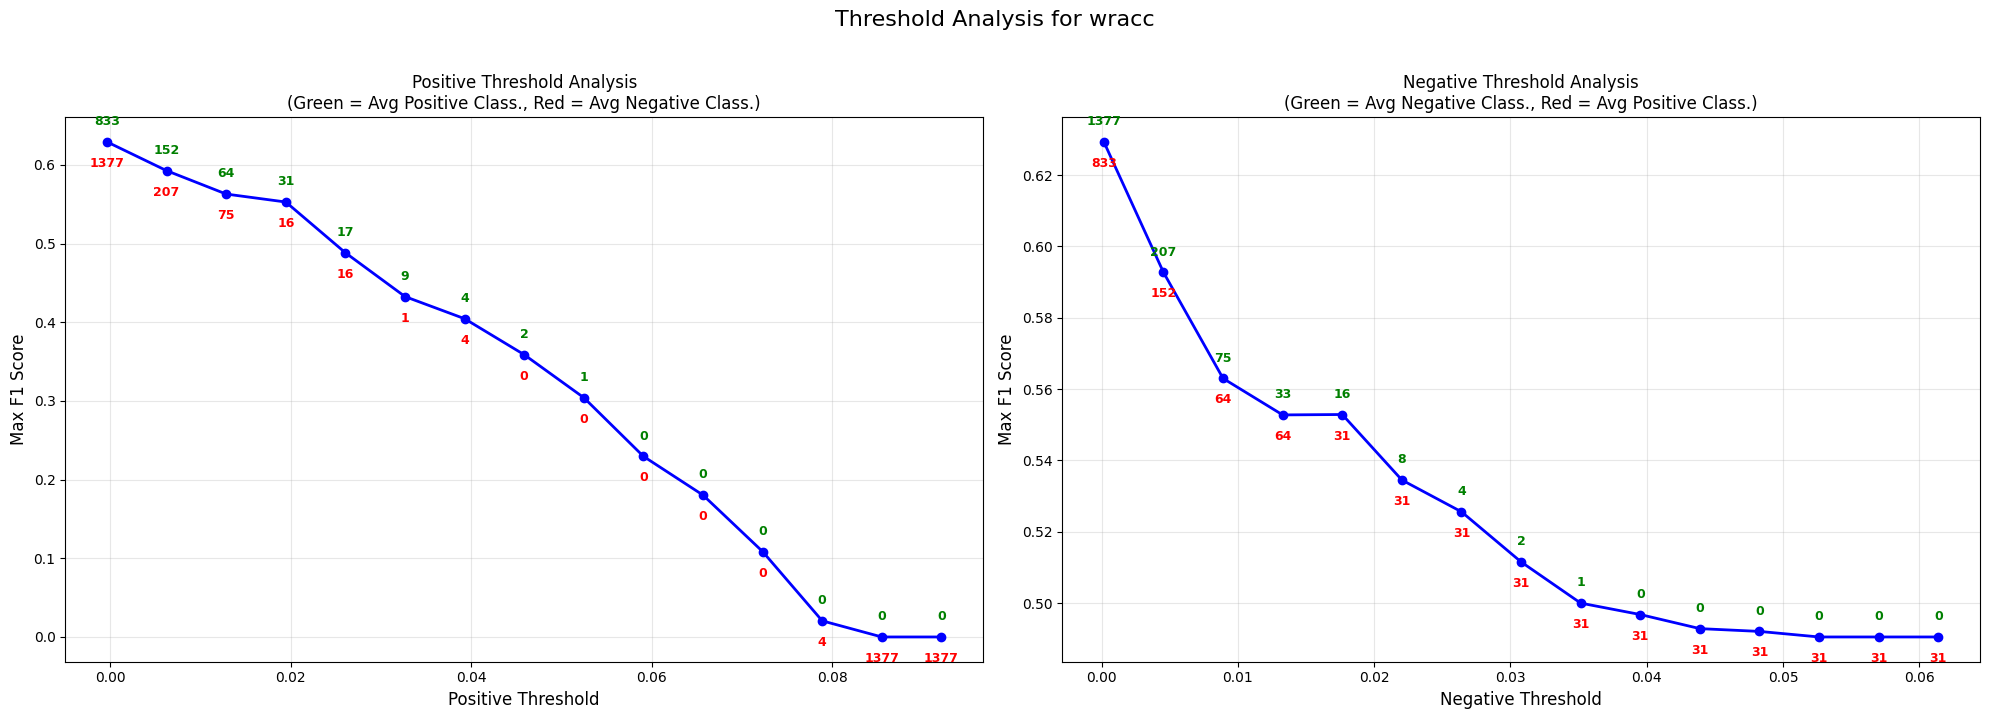


Metric: balanced_precision_proxy

Positive Threshold Analysis:
  Best threshold: -0.001731
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000799
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


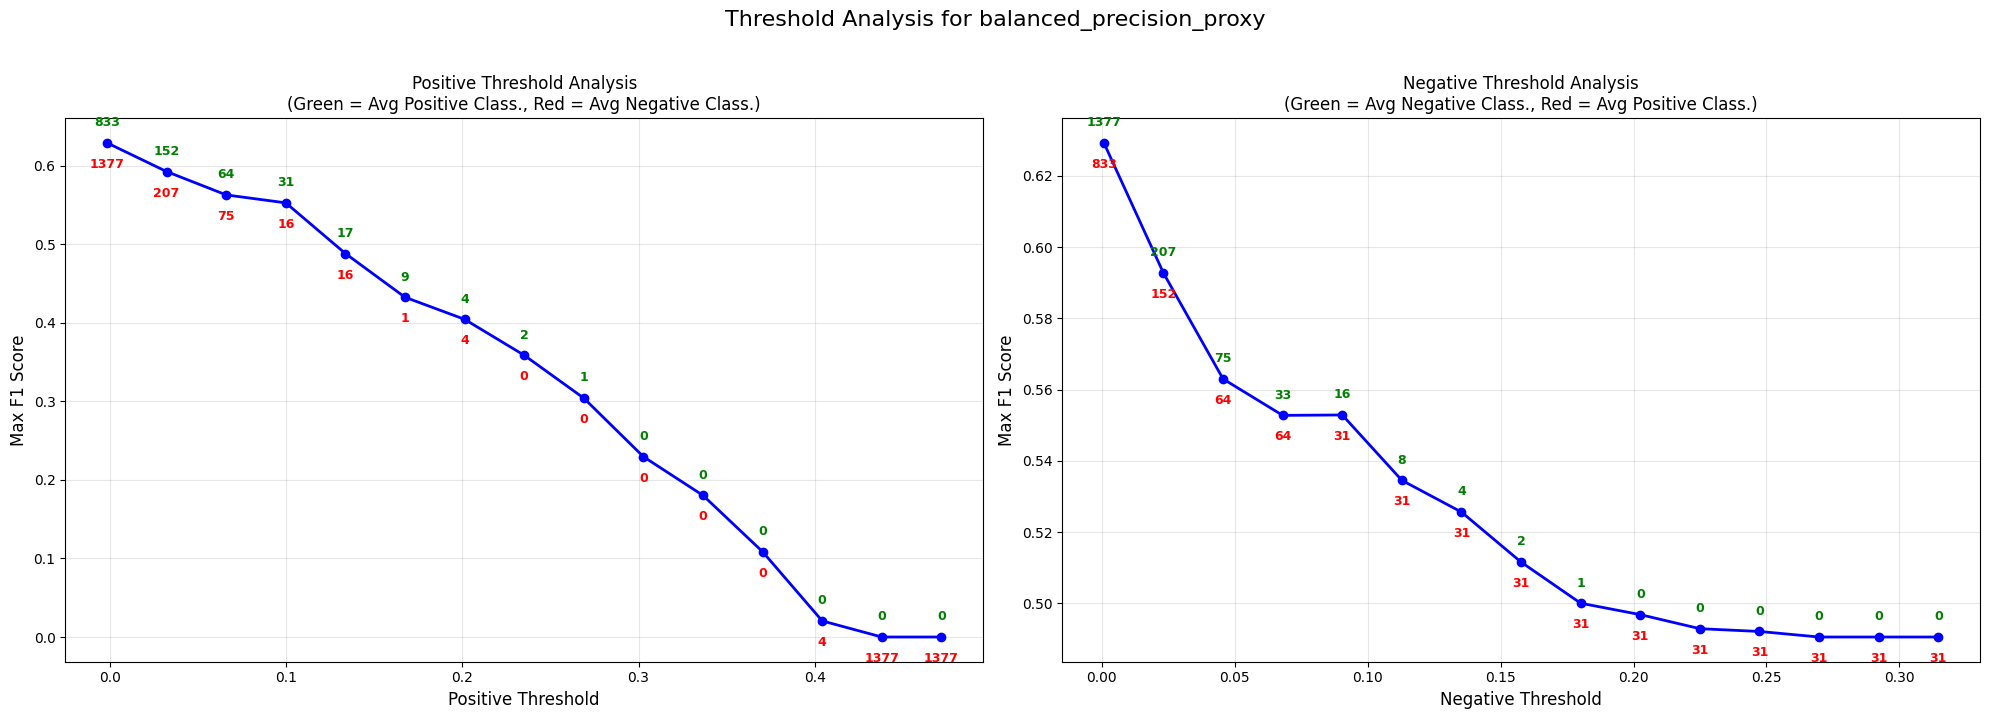


Metric: youdens_j

Positive Threshold Analysis:
  Best threshold: -0.001731
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000799
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


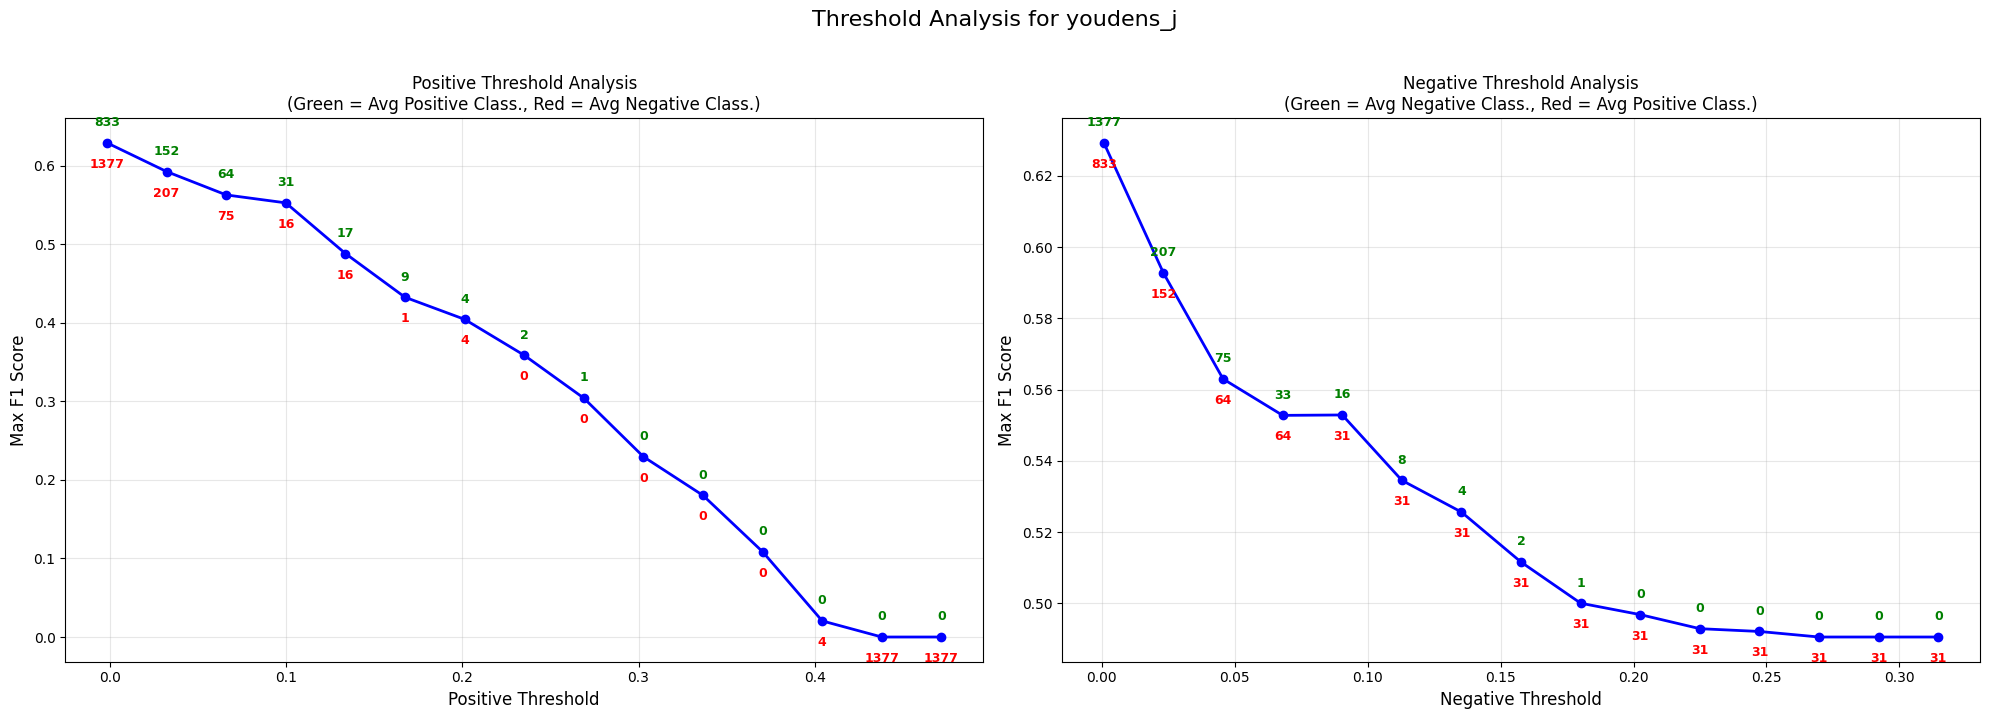


Metric: matthews_correlation

Positive Threshold Analysis:
  Best threshold: -0.001644
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.007261
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


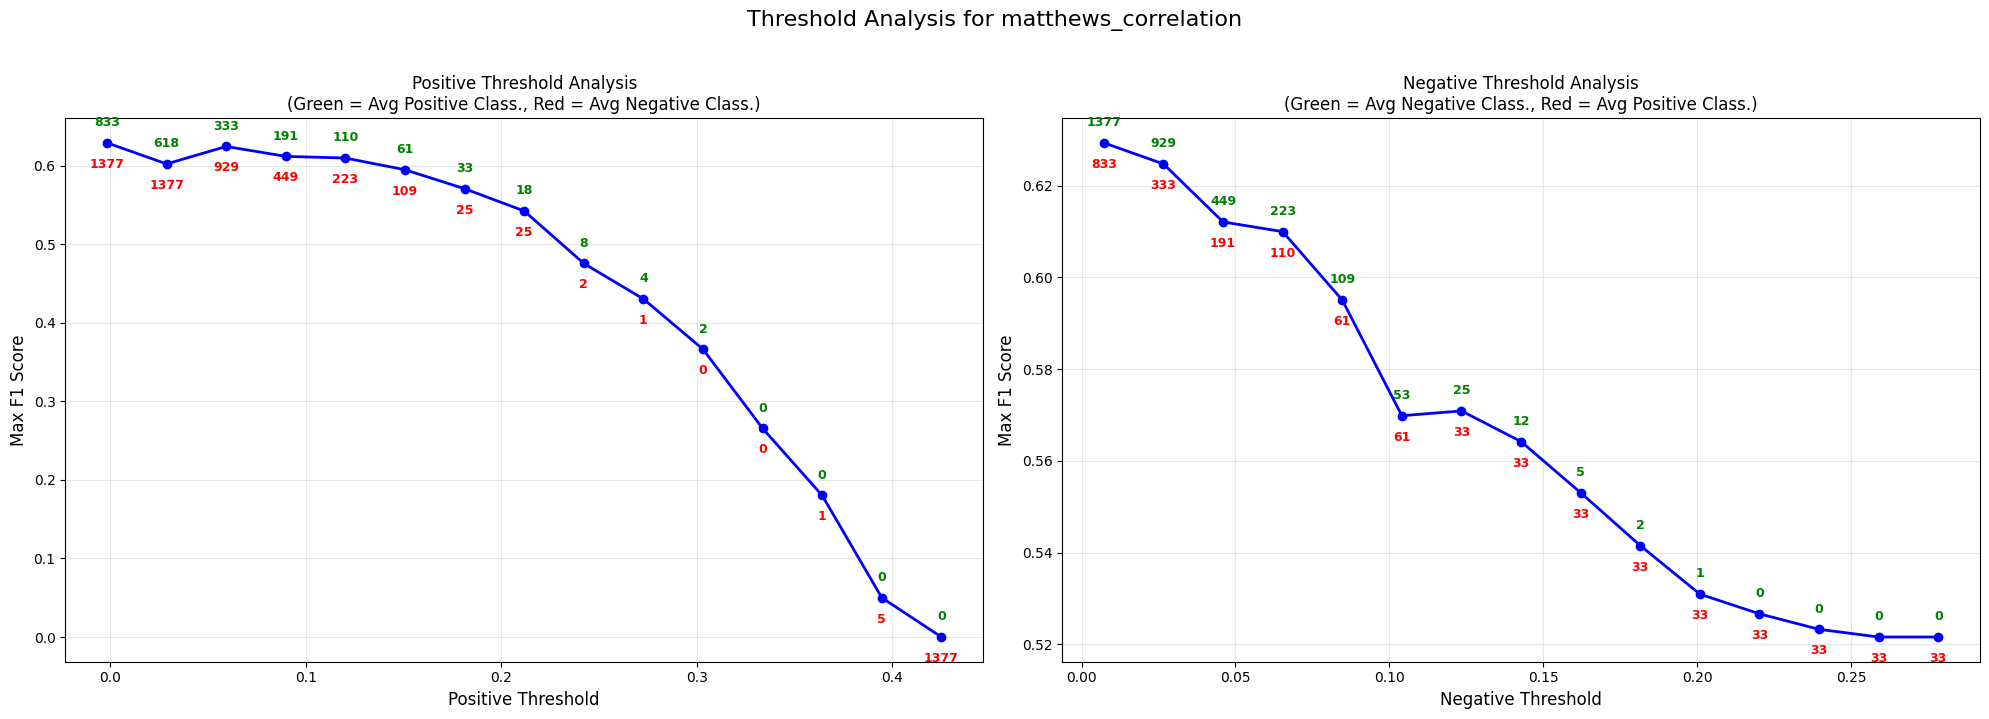


Metric: information_gain

Positive Threshold Analysis:
  Best threshold: 0.000000
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000040
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


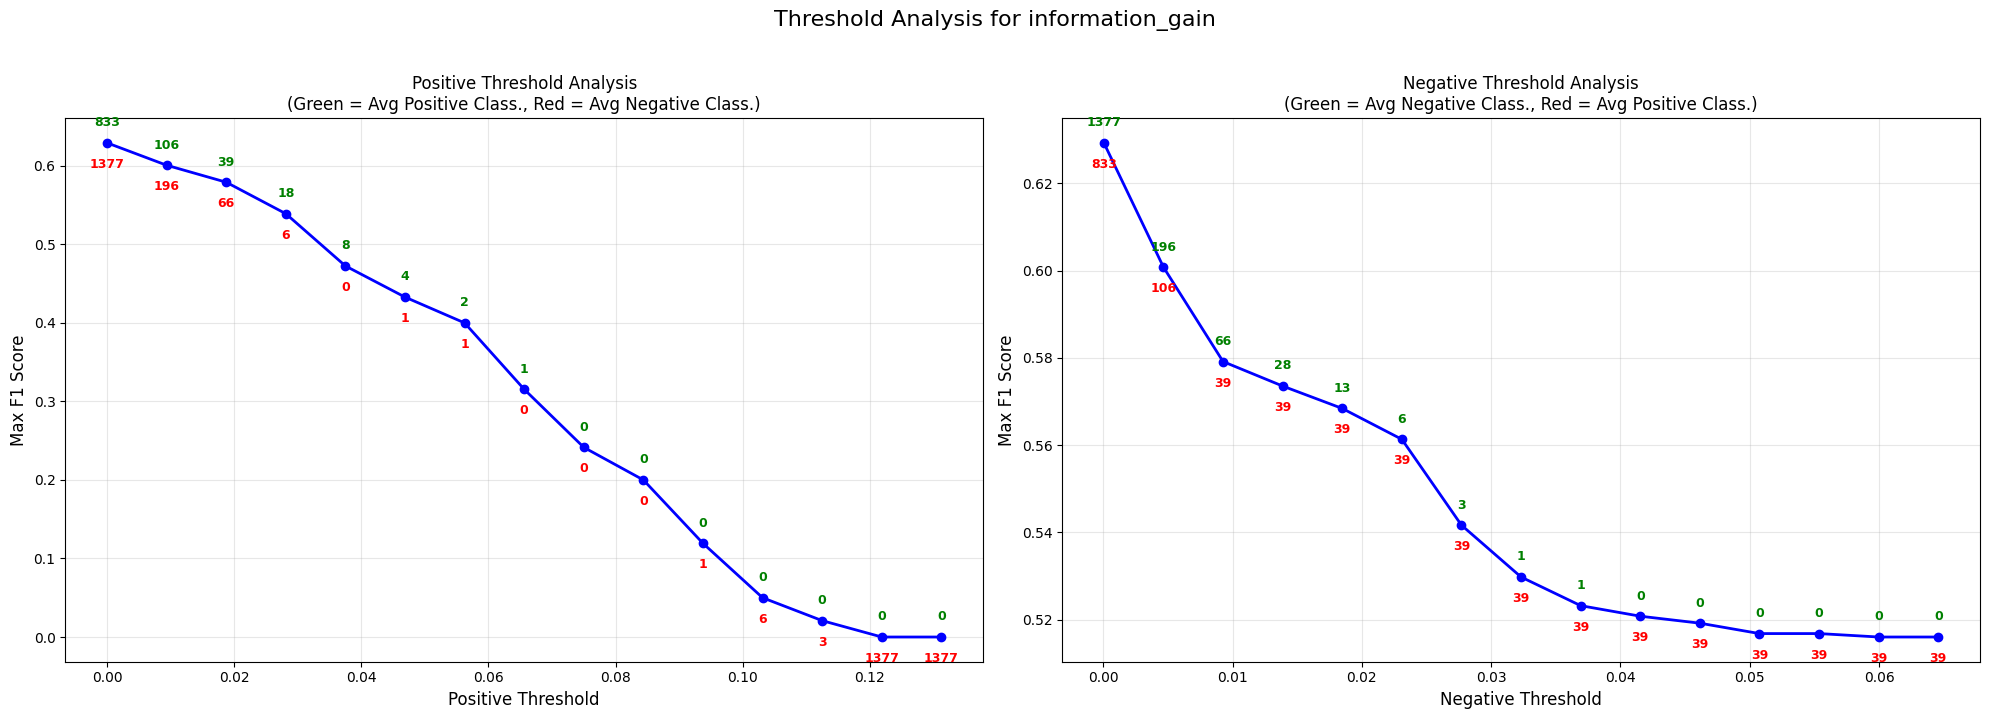


Metric: gini_gain

Positive Threshold Analysis:
  Best threshold: 0.000000
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000021
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


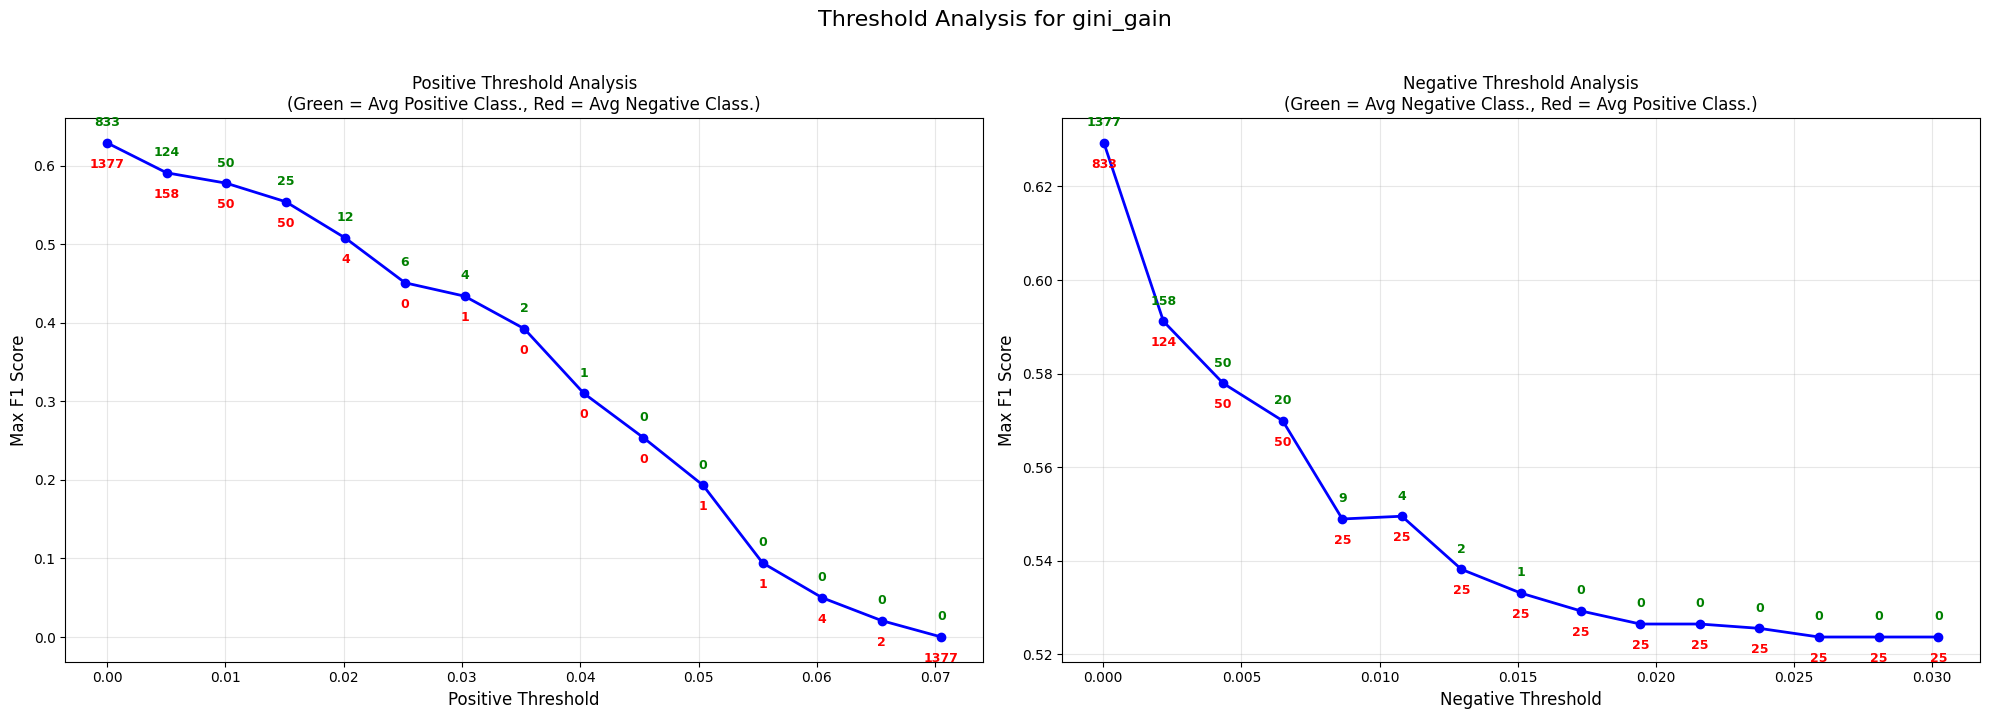


Metric: log_odds_ratio

Positive Threshold Analysis:
  Best threshold: 0.360272
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 3.571429
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


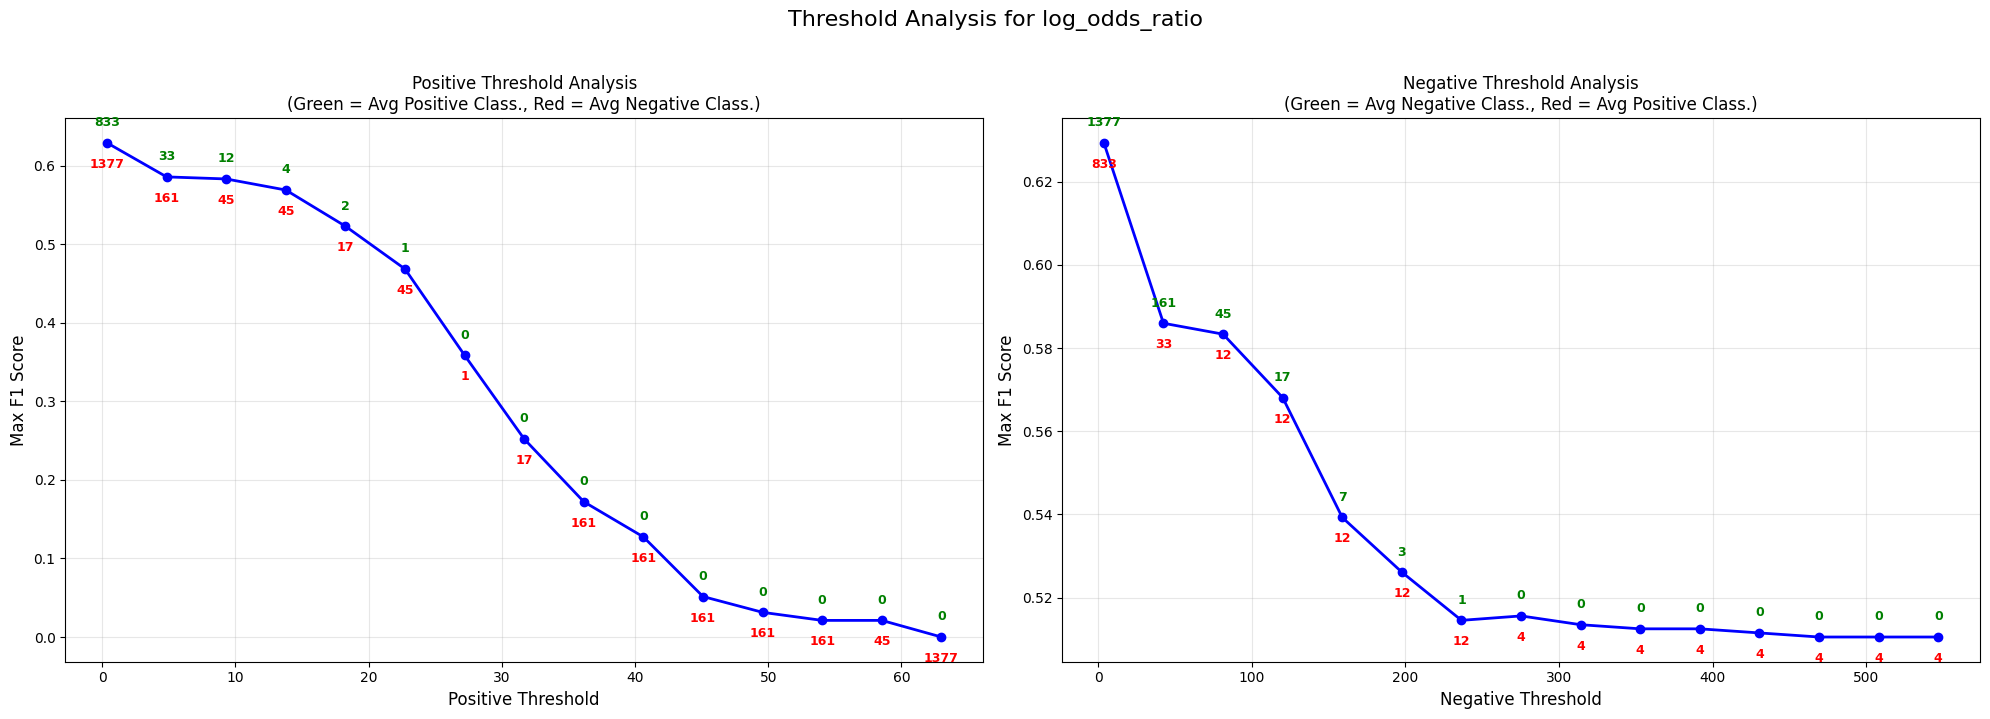


Metric: chi_squared

Positive Threshold Analysis:
  Best threshold: 0.000000
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.333609
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


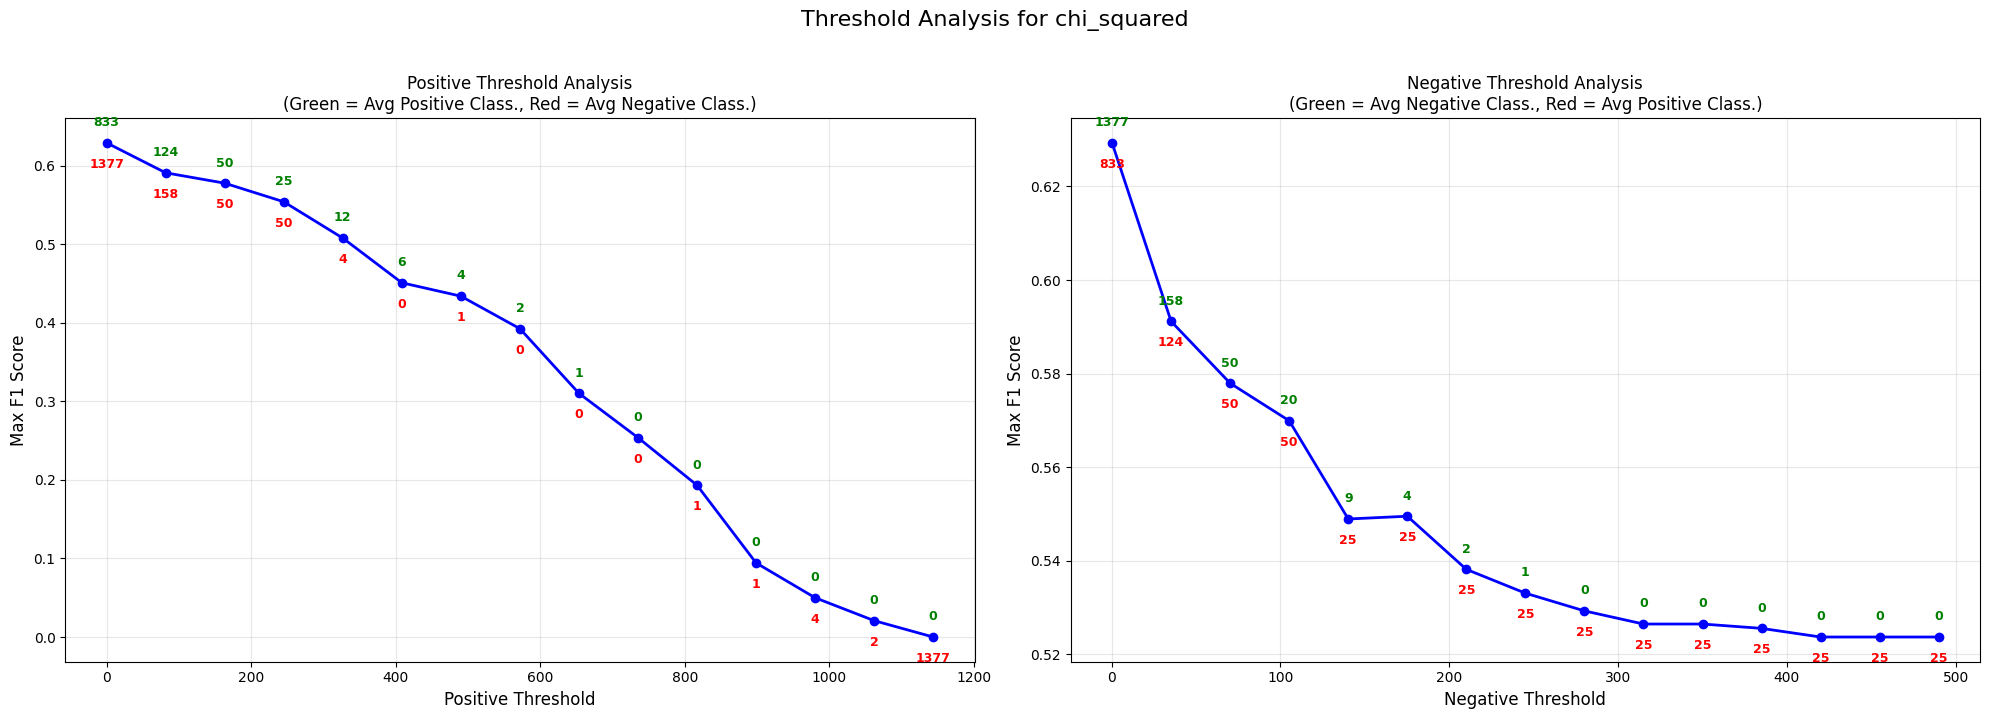


Metric: g_test

Positive Threshold Analysis:
  Best threshold: 0.000000
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.354184
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


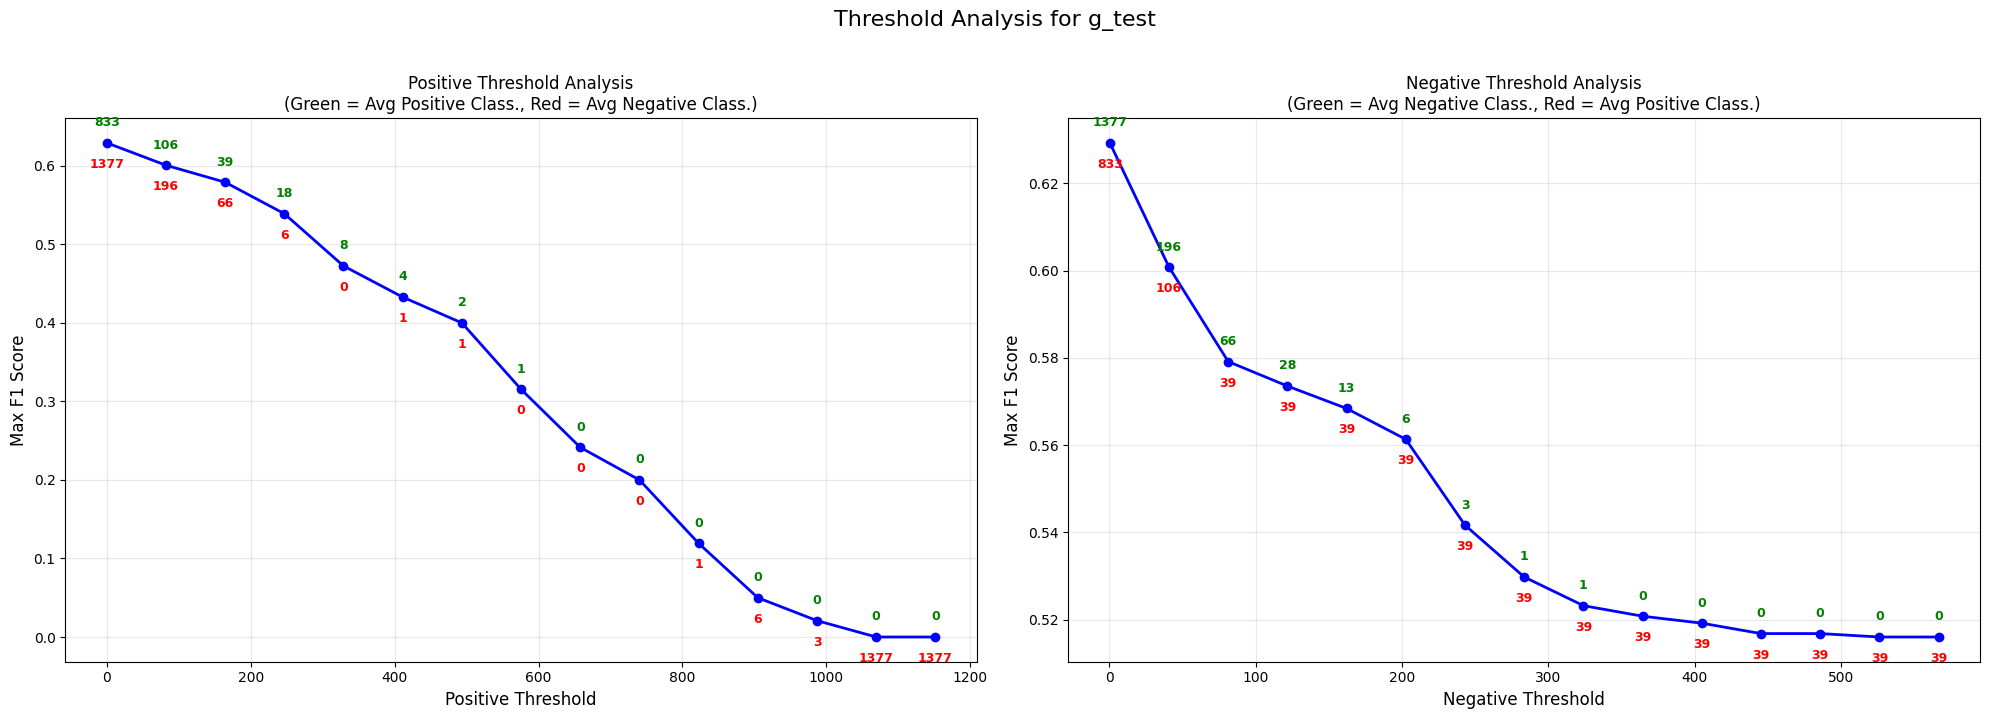


Metric: interval_tightness

Positive Threshold Analysis:
  Best threshold: 0.159223
  Max F1 score: 0.633406
  Avg positive classifications: 828
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.016434
  Max F1 score: 0.633406
  Avg negative classifications: 1377
  Avg positive classifications: 828


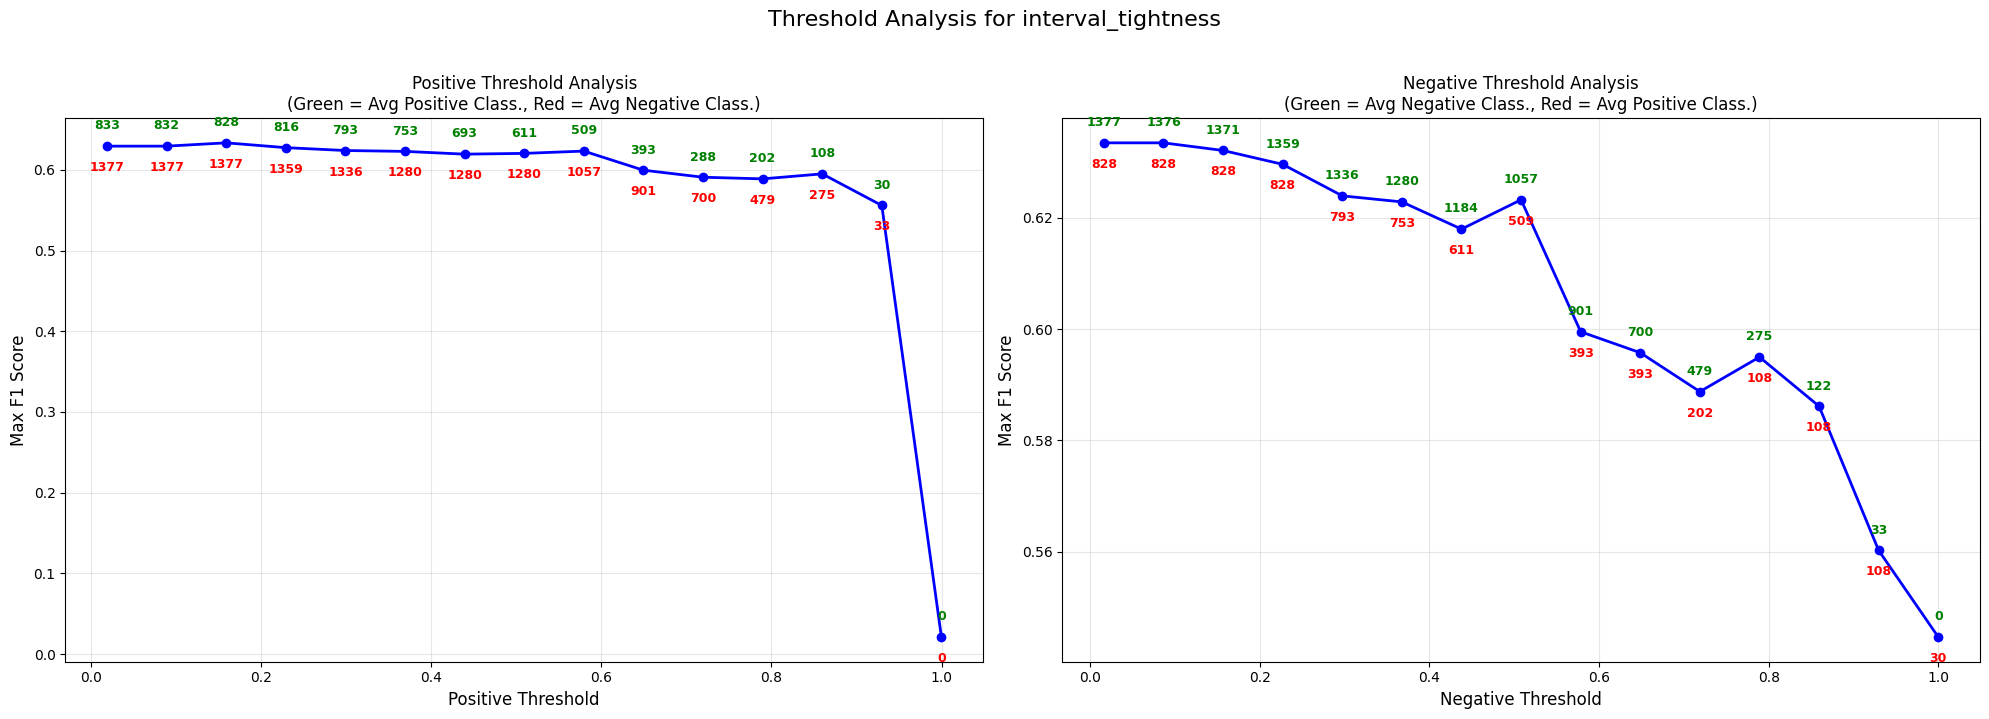


Metric: description_volume

Positive Threshold Analysis:
  Best threshold: 0.527771
  Max F1 score: 0.633406
  Avg positive classifications: 829
  Avg negative classifications: 1375

Negative Threshold Analysis:
  Best threshold: 0.601277
  Max F1 score: 0.633406
  Avg negative classifications: 1375
  Avg positive classifications: 829


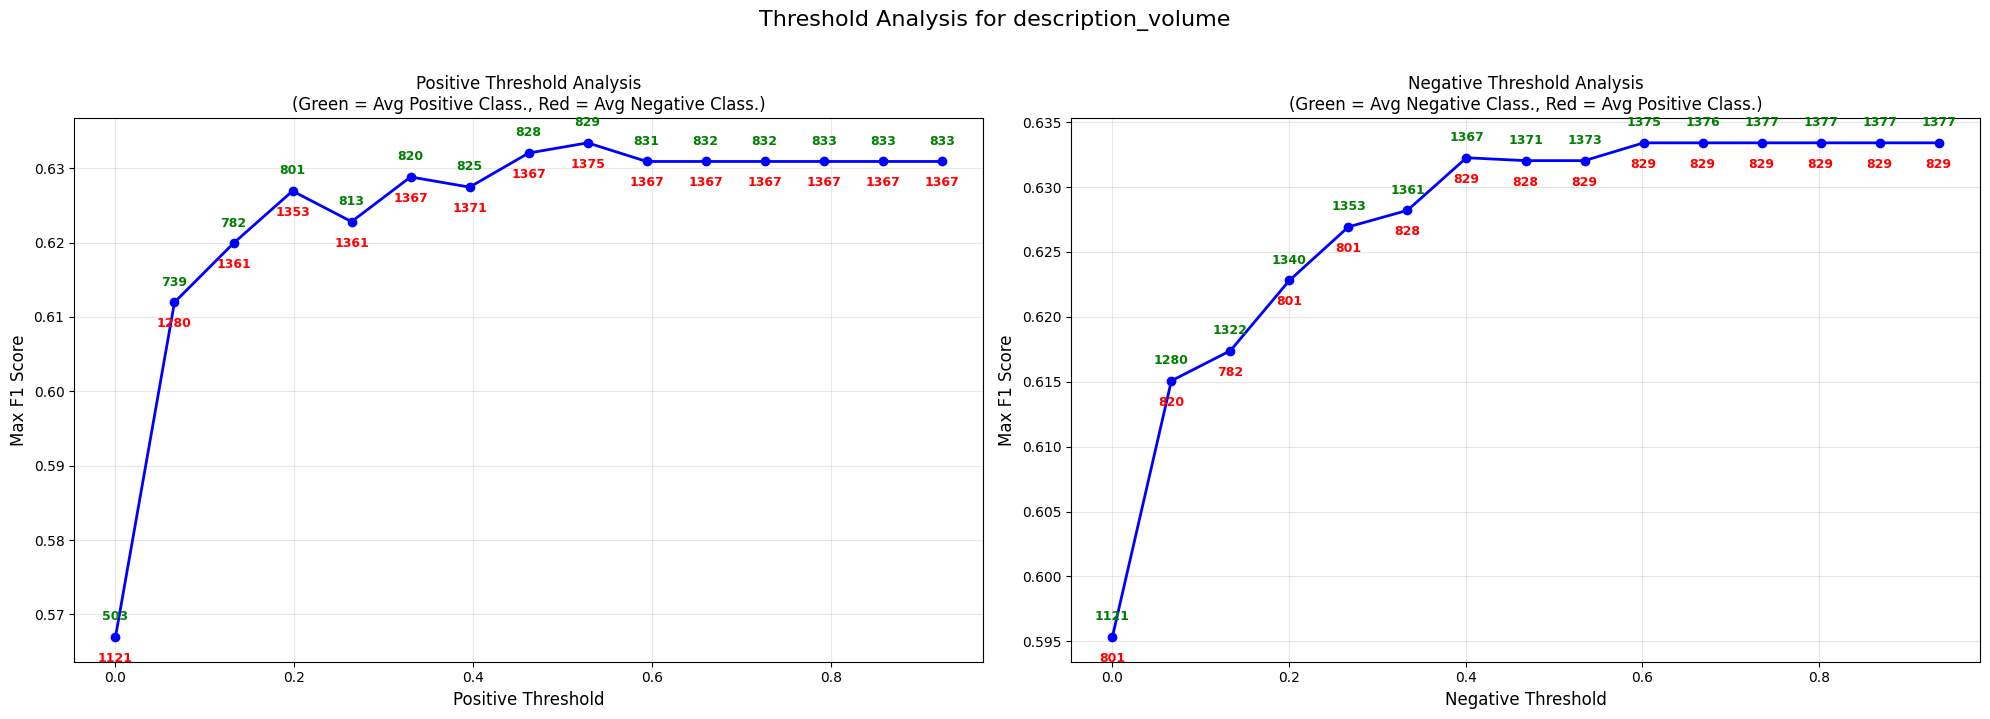


Metric: simplicity_prior

Positive Threshold Analysis:
  Best threshold: 0.495503
  Max F1 score: 0.631808
  Avg positive classifications: 827
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.463801
  Max F1 score: 0.631808
  Avg negative classifications: 1377
  Avg positive classifications: 827


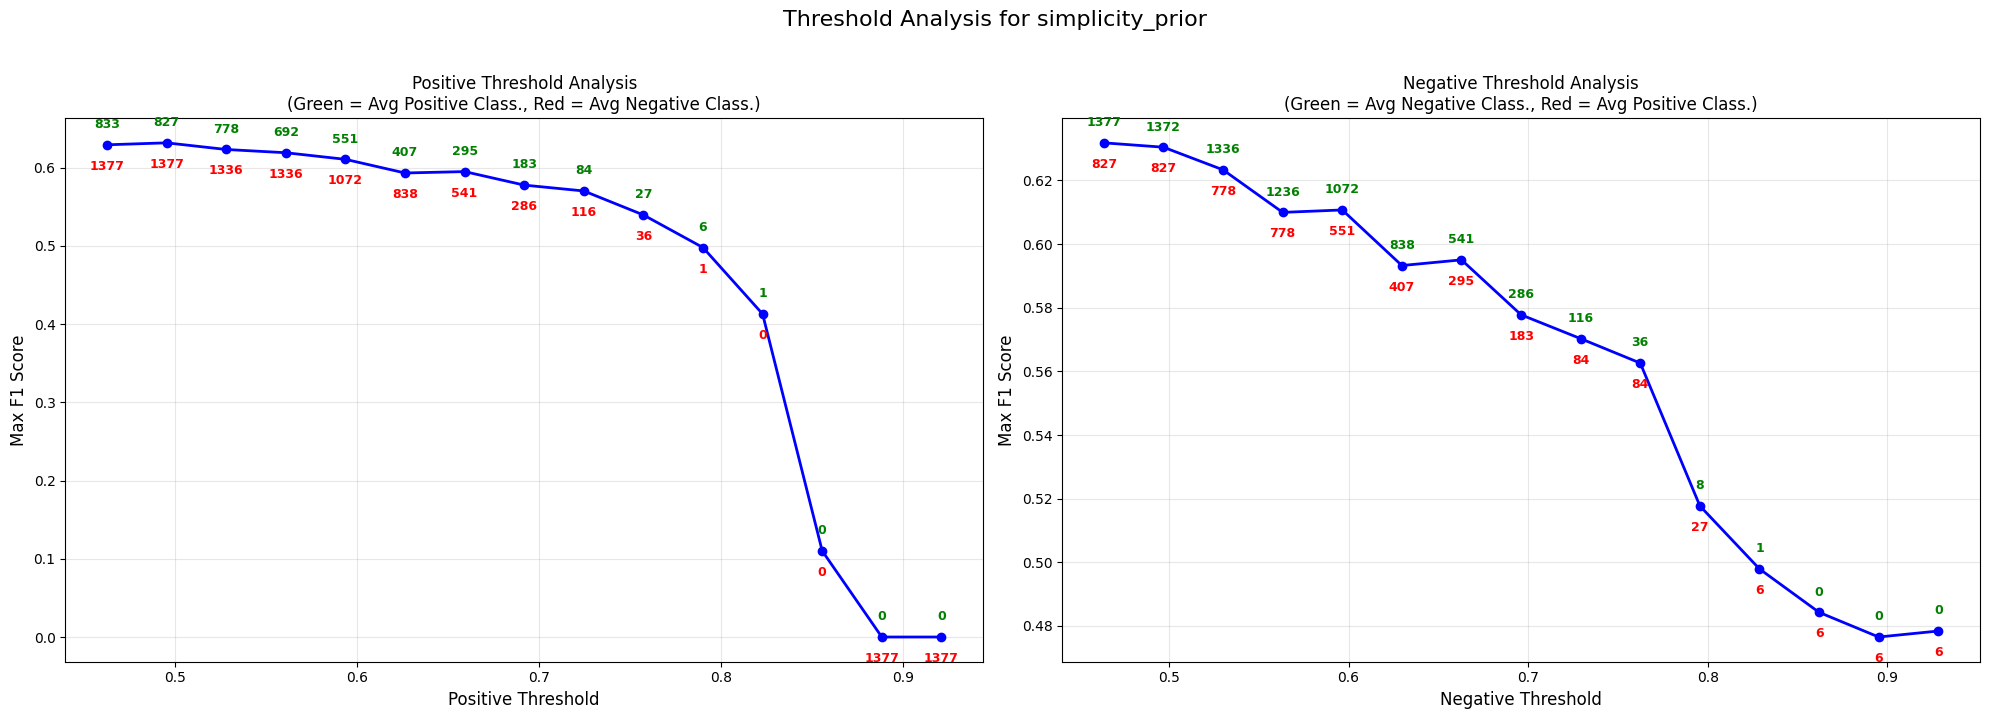


Metric: query_binary_similarity

Positive Threshold Analysis:
  Best threshold: 0.142857
  Max F1 score: 0.630670
  Avg positive classifications: 828
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000000
  Max F1 score: 0.630670
  Avg negative classifications: 1377
  Avg positive classifications: 828


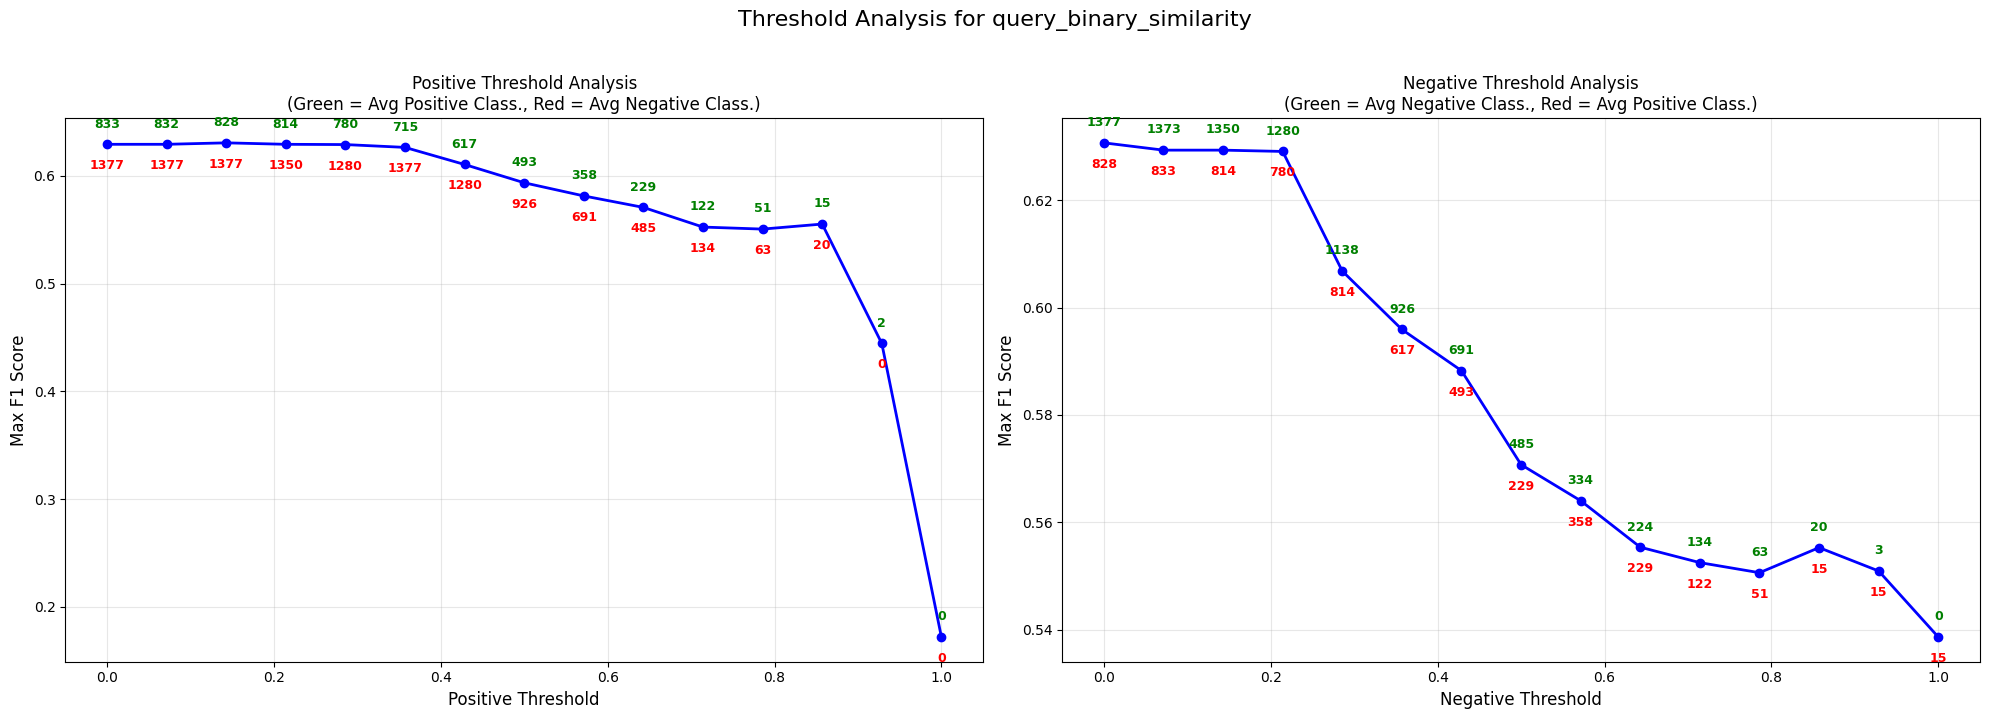


Metric: query_numeric_similarity

Positive Threshold Analysis:
  Best threshold: 0.159223
  Max F1 score: 0.633406
  Avg positive classifications: 828
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.016434
  Max F1 score: 0.633406
  Avg negative classifications: 1377
  Avg positive classifications: 828


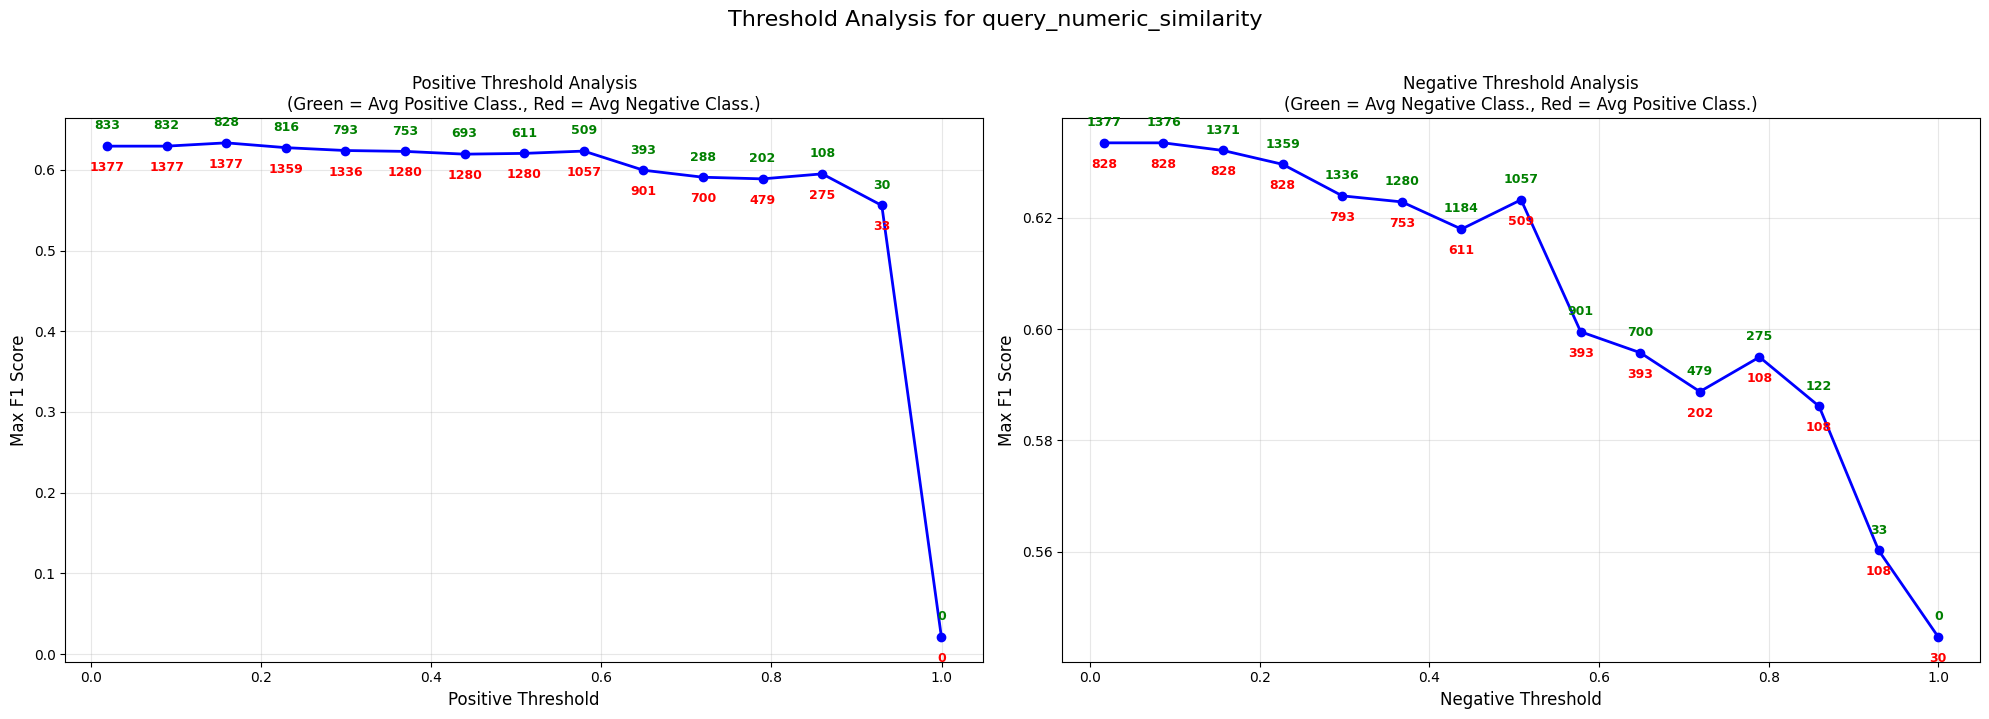


Metric: query_similarity

Positive Threshold Analysis:
  Best threshold: 0.022976
  Max F1 score: 0.632258
  Avg positive classifications: 833
  Avg negative classifications: 1357

Negative Threshold Analysis:
  Best threshold: 0.261597
  Max F1 score: 0.632258
  Avg negative classifications: 1357
  Avg positive classifications: 833


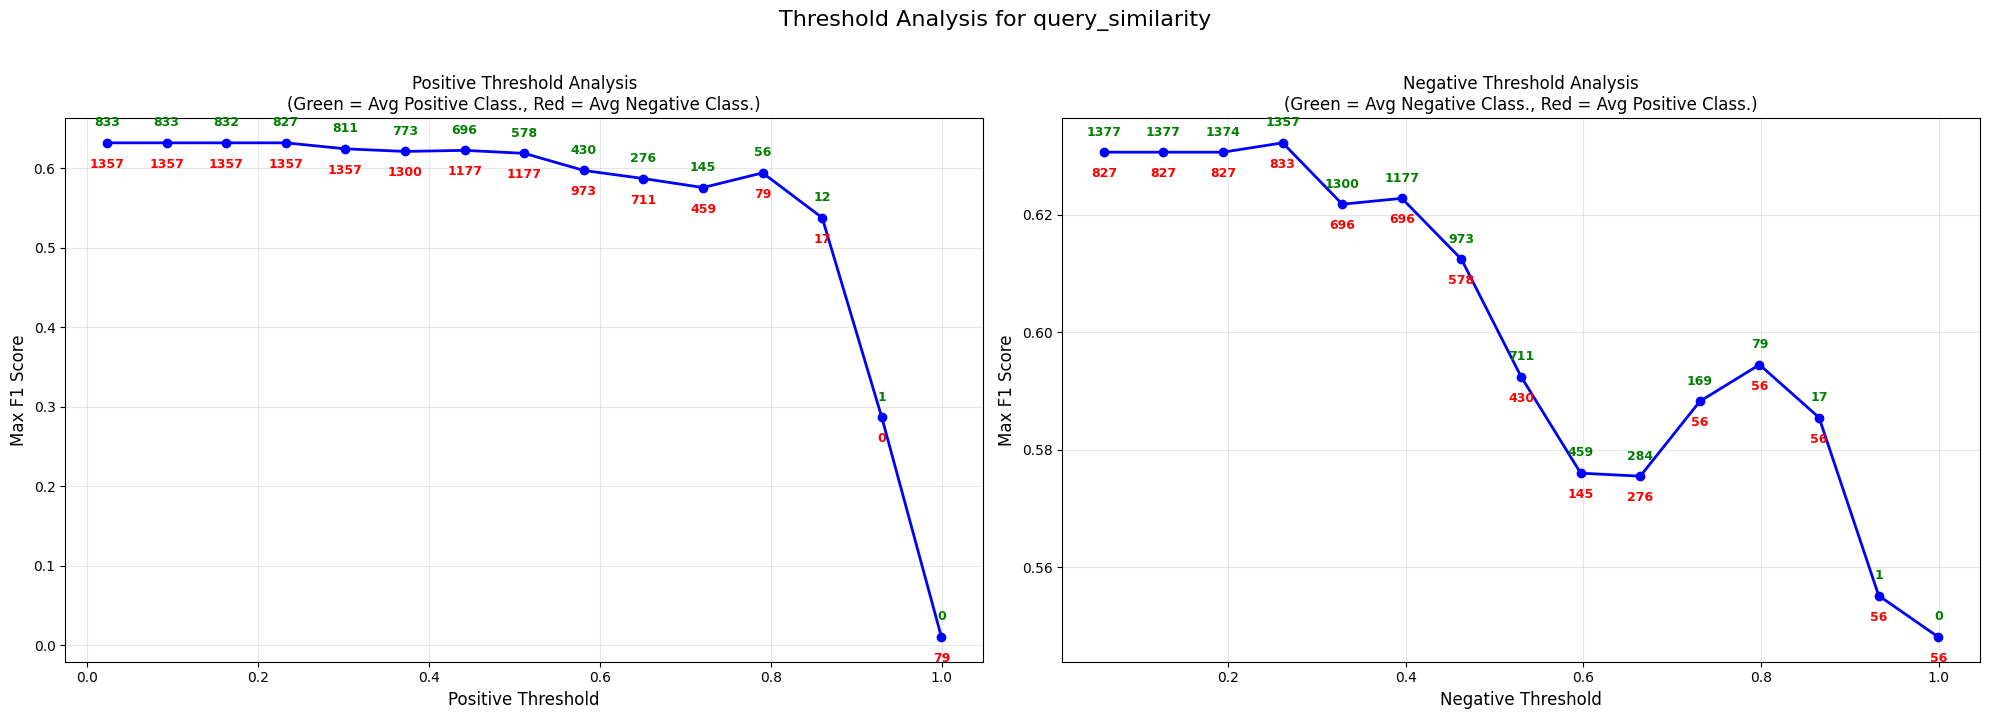


Metric: query_weighted_precision

Positive Threshold Analysis:
  Best threshold: 0.078122
  Max F1 score: 0.630670
  Avg positive classifications: 829
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.049604
  Max F1 score: 0.630670
  Avg negative classifications: 1377
  Avg positive classifications: 829


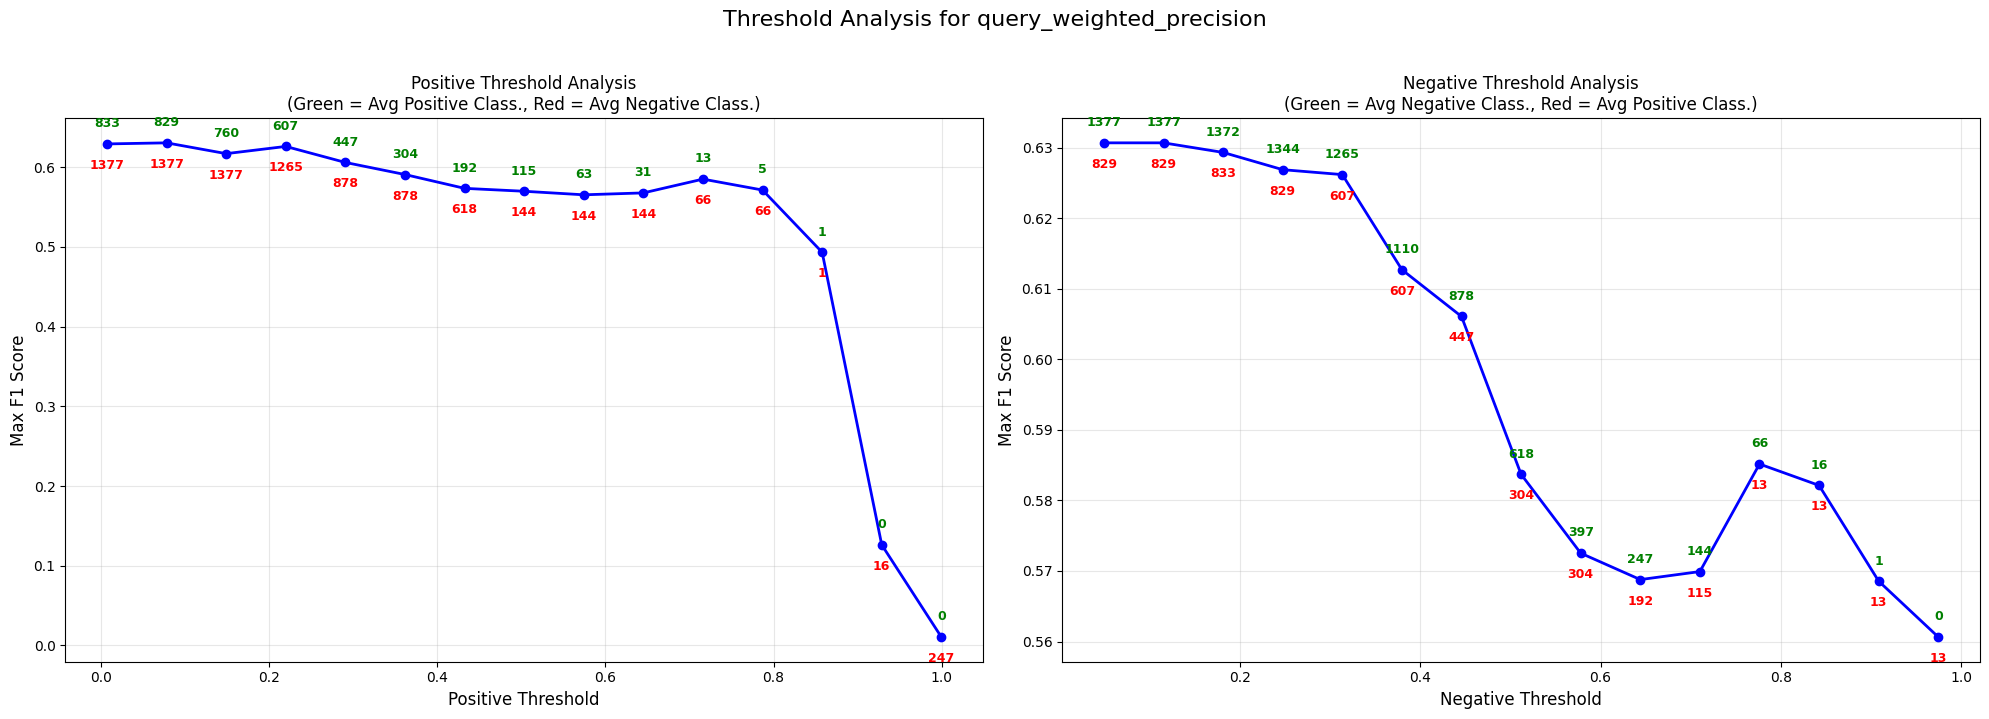


Metric: query_weighted_wracc

Positive Threshold Analysis:
  Best threshold: -0.000078
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000041
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


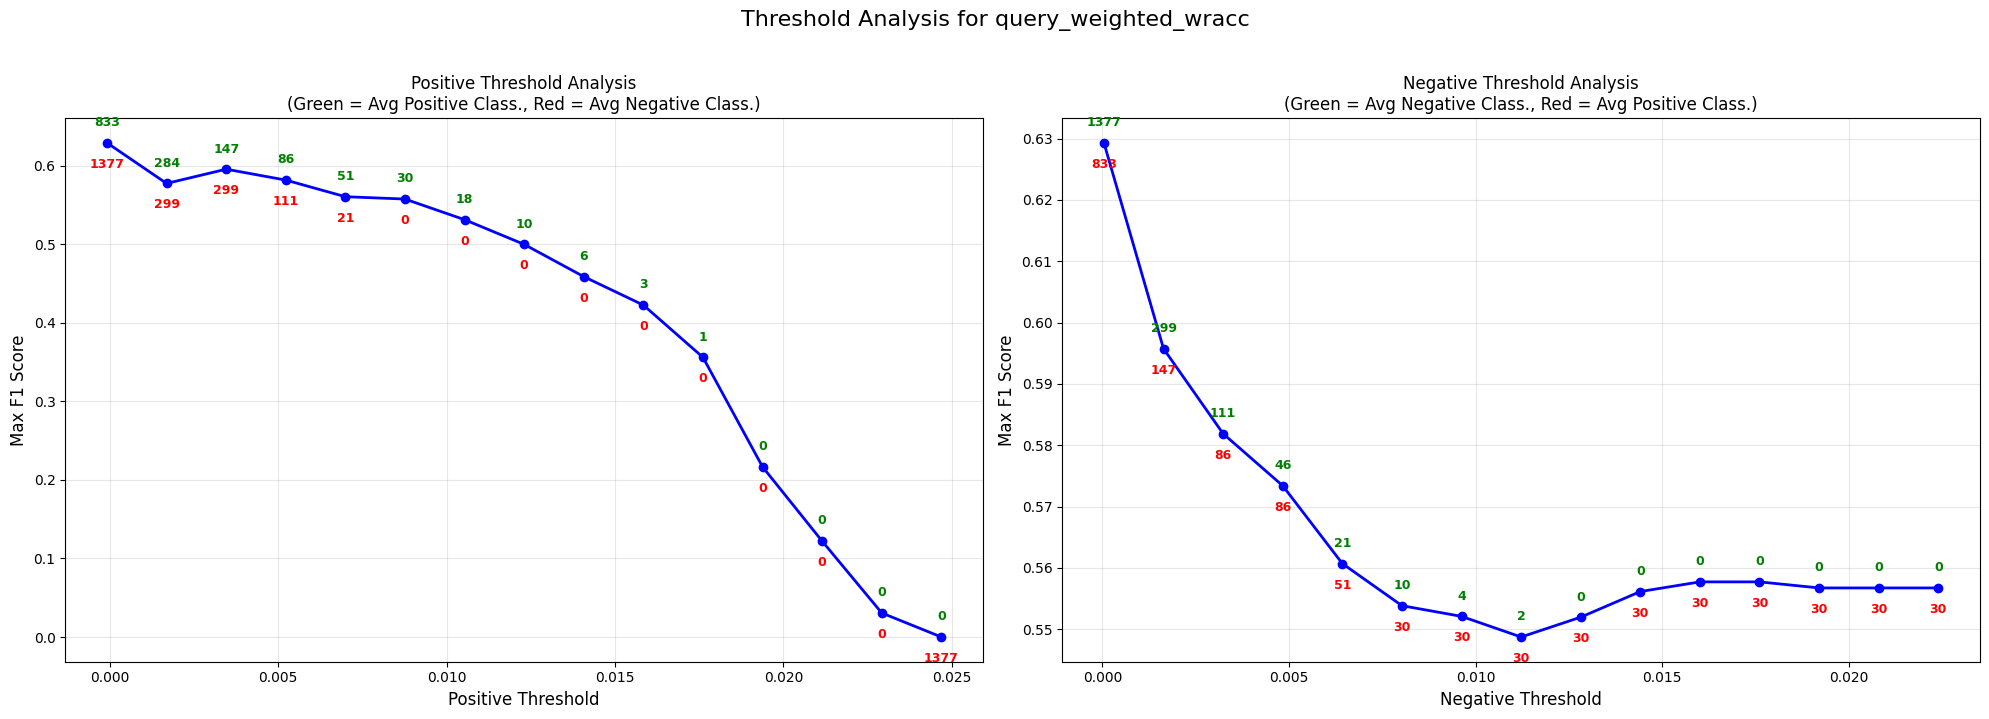


Metric: stability

Positive Threshold Analysis:
  Best threshold: 0.000086
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000122
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


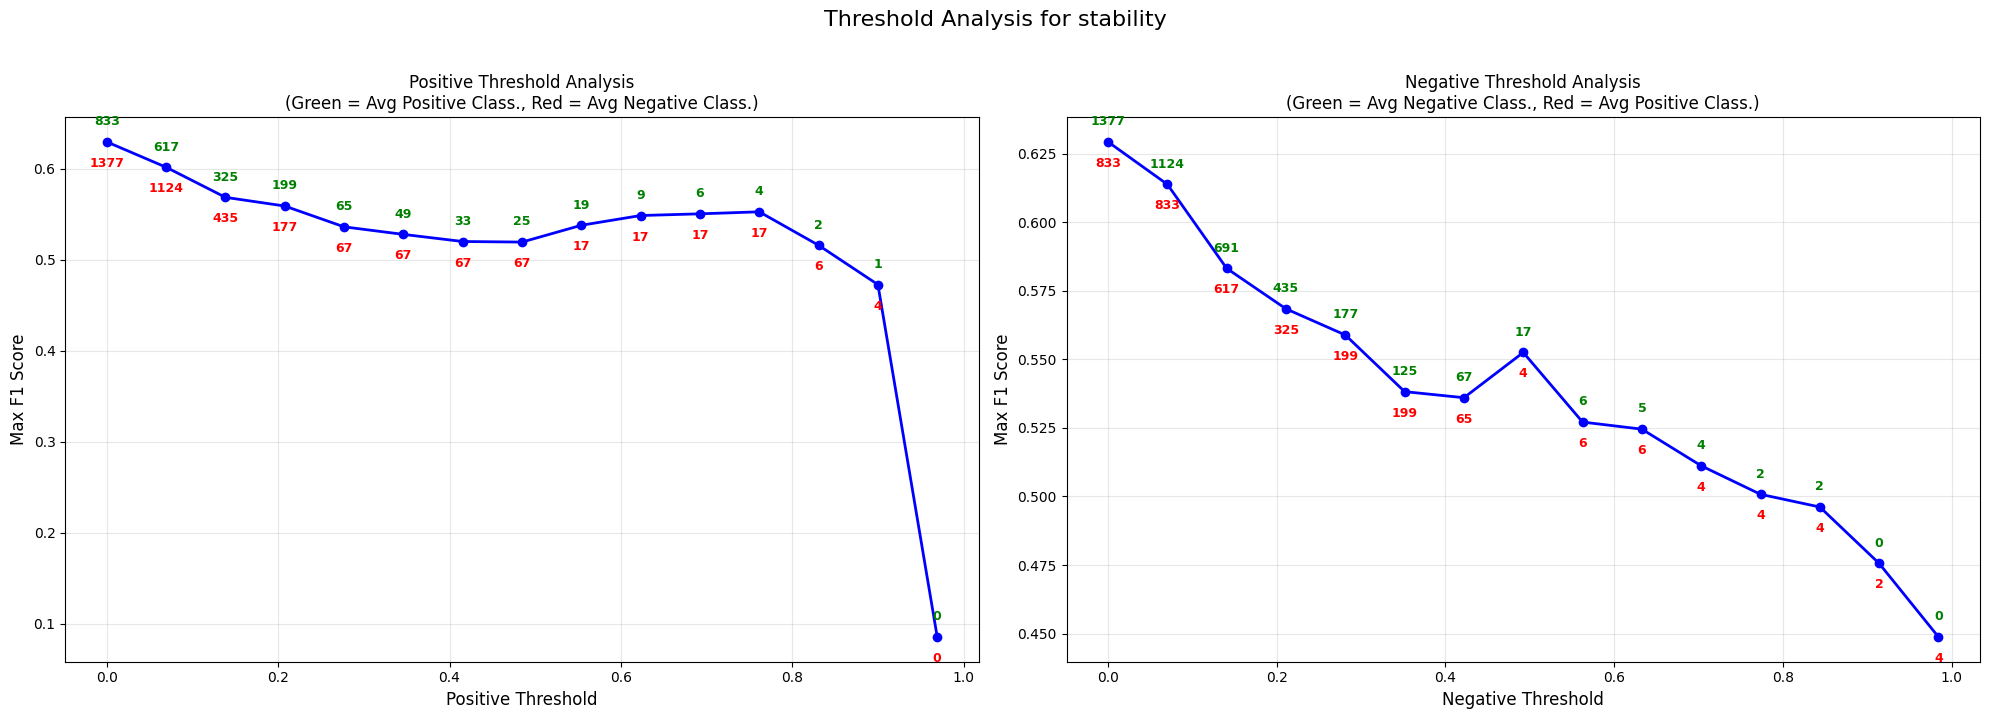


Metric: robustness

Positive Threshold Analysis:
  Best threshold: 0.000086
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 0.000122
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


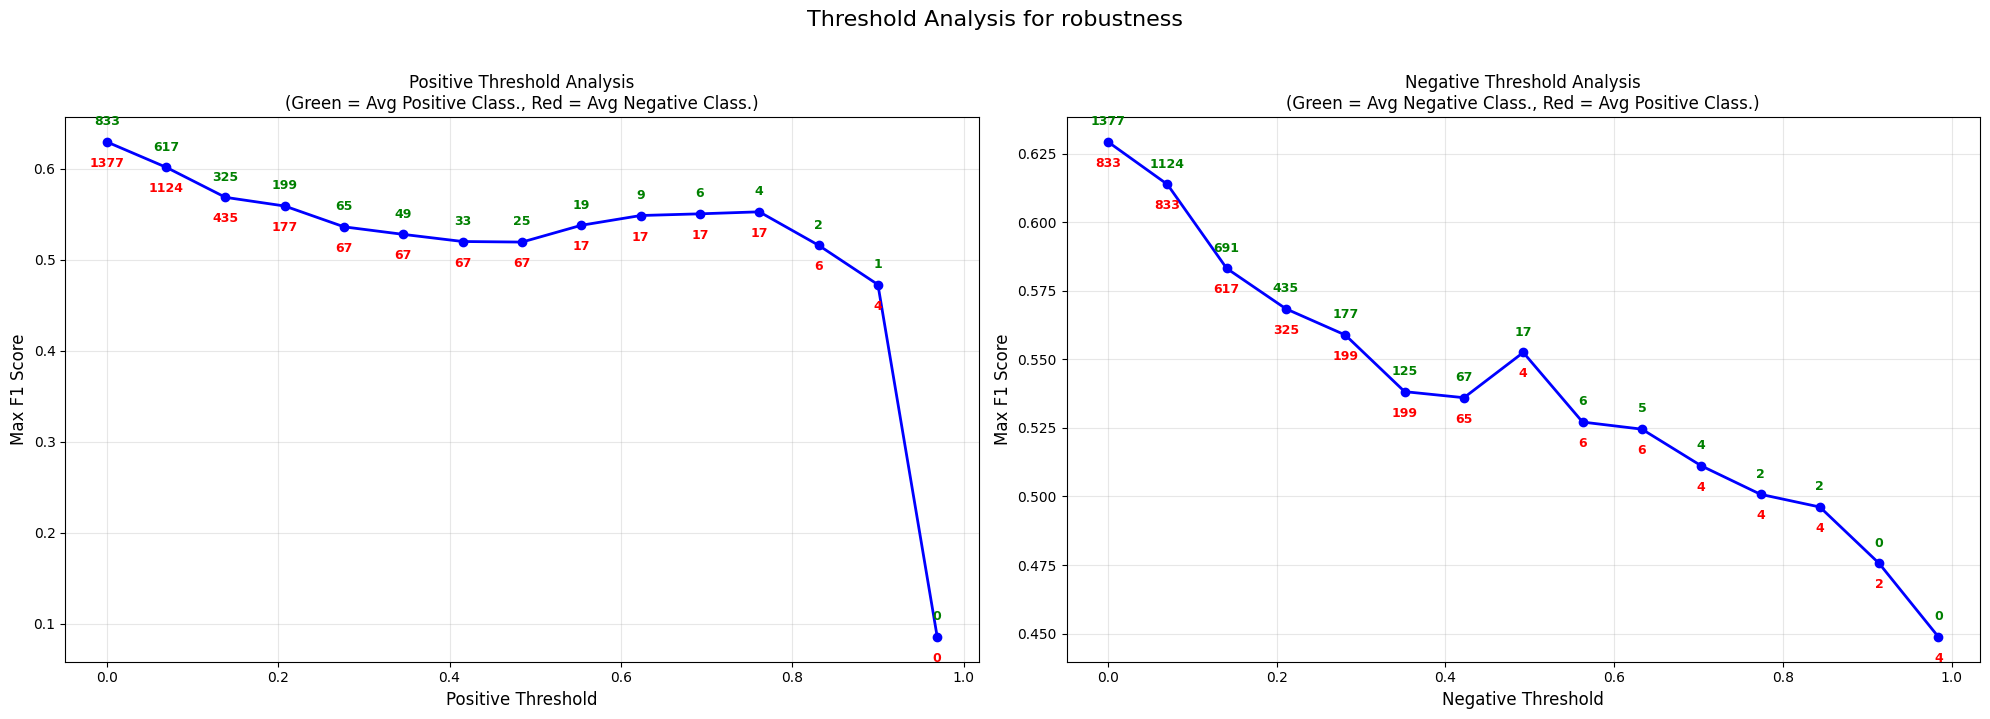


Metric: delta_stability

Positive Threshold Analysis:
  Best threshold: 1.000000
  Max F1 score: 0.629310
  Avg positive classifications: 833
  Avg negative classifications: 1377

Negative Threshold Analysis:
  Best threshold: 1.000000
  Max F1 score: 0.629310
  Avg negative classifications: 1377
  Avg positive classifications: 833


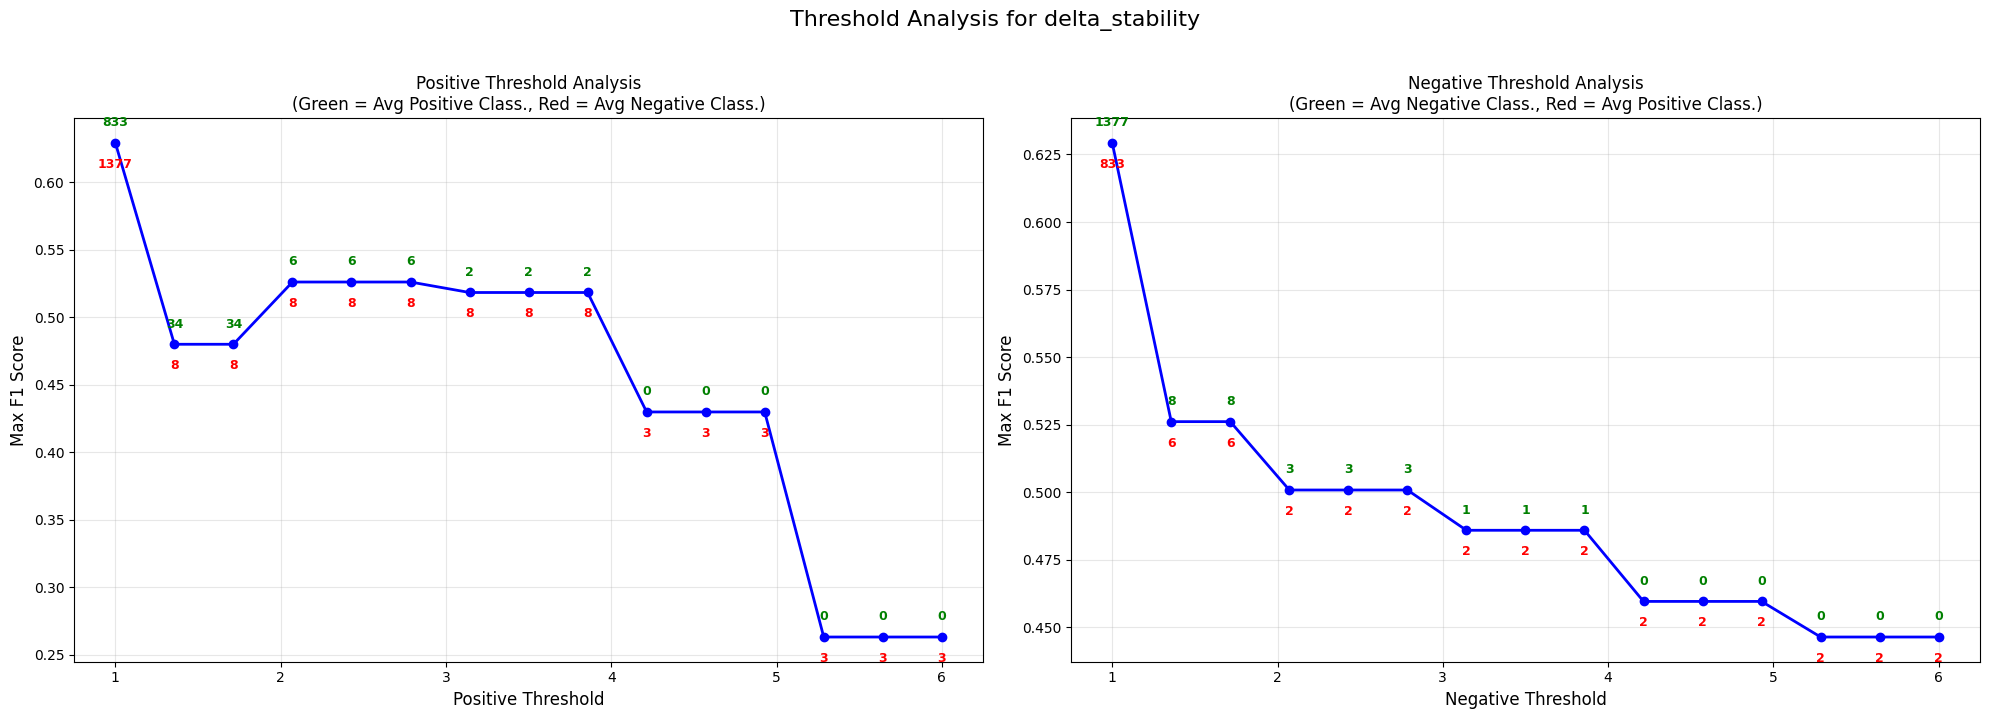

In [5]:
# Plot all metrics
for metric in metrics:
    print(f"\n{'='*80}")
    print(f"Metric: {metric}")
    print(f"{'='*80}")
    plot_both_thresholds_vs_f1(df, metric)

In [6]:
# Summary: Best F1-score for each metric
best_per_metric = []
for metric in df['metric_name'].unique():
    metric_data = df[df['metric_name'] == metric]
    best_row = metric_data.loc[metric_data['F1-score'].idxmax()]
    best_per_metric.append({
        'metric_name': metric,
        'best_f1_score': best_row['F1-score'],
        'best_pos_threshold': best_row['pos_threshold'],
        'best_neg_threshold': best_row['neg_threshold'],
        'avg_pos_classifications': int(best_row['avg_positive_classifications']),
        'avg_neg_classifications': int(best_row['avg_negative_classifications']),
    })

summary_df = pd.DataFrame(best_per_metric).sort_values('best_f1_score', ascending=False)
print("Best F1-score for each metric:\n")
summary_df

Best F1-score for each metric:



,metric_name,best_f1_score,best_pos_threshold,best_neg_threshold,avg_pos_classifications,avg_neg_classifications
18,query_numeric_similarity,0.633406,1.592226e-01,0.016434,828,1377
15,description_volume,0.633406,5.277706e-01,0.601277,829,1375
14,interval_tightness,0.633406,1.592226e-01,0.016434,828,1377
0,opposers_covered,0.632258,5.652857e+02,58.142857,825,1335
2,error_rate,0.632258,1.216715e-01,0.034568,825,1335
19,query_similarity,0.632258,2.297628e-02,0.261597,833,1357
16,simplicity_prior,0.631808,4.955028e-01,0.463801,827,1377
20,query_weighted_precision,0.630670,7.812230e-02,0.049604,829,1377
17,query_binary_similarity,0.630670,1.428571e-01,0.000000,828,1377
13,g_test,0.629310,1.454907e-07,0.354184,833,1377


## Results

...